# Import

In [185]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from tqdm.auto import tqdm  
from data_fitting.module_fitzcu import *
from data_fitting.abcd_rf_fit import *
from singleshotplot import hist as histplot
from qick import *
from qick.asm_v2 import AveragerProgramV2
from qick.asm_v2 import QickSpan, QickSweep1D
from qick.asm_v2 import AsmV2
import json
import datetime
import pprint as pp
from yamltool import yml_comment

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [190]:
import Pyro4
from qick import QickConfig
Pyro4.config.SERIALIZER = "pickle"
Pyro4.config.PICKLE_PROTOCOL_VERSION=4

ns_host = "192.168.10.212"
ns_port = 8888
proxy_name = "myqick"

ns = Pyro4.locateNS(host=ns_host, port=ns_port)
soc = Pyro4.Proxy(ns.lookup(proxy_name))
soccfg = QickConfig(soc.get_cfg())
print(soccfg)

QICK library version mismatch: 0.2.302 remote (the board), 0.2.325 local (the PC)
                        This may cause errors, usually KeyError in QickConfig initialization.
                        If this happens, you must bring your versions in sync.


QICK running on ZCU216, software version 0.2.302

Firmware configuration (built Tue Sep 10 16:13:40 2024):

	Global clocks (MHz): tProcessor 430.080, RF reference 245.760

	16 signal generator channels:
	0:	axis_signal_gen_v6 - envelope memory 16384 samples (1.709 us)
		fs=9584.640 MHz, fabric=599.040 MHz, 32-bit DDS, range=9584.640 MHz
		DAC tile 2, blk 0 is 0_230, on JHC3
	1:	axis_signal_gen_v6 - envelope memory 4096 samples (0.427 us)
		fs=9584.640 MHz, fabric=599.040 MHz, 32-bit DDS, range=9584.640 MHz
		DAC tile 2, blk 1 is 1_230, on JHC4
	2:	axis_signal_gen_v6 - envelope memory 8192 samples (0.855 us)
		fs=9584.640 MHz, fabric=599.040 MHz, 32-bit DDS, range=9584.640 MHz
		DAC tile 2, blk 2 is 2_230, on JHC3
	3:	axis_signal_gen_v6 - envelope memory 4096 samples (0.427 us)
		fs=9584.640 MHz, fabric=599.040 MHz, 32-bit DDS, range=9584.640 MHz
		DAC tile 2, blk 3 is 3_230, on JHC4
	4:	axis_sg_int4_v2 - envelope memory 16384 samples (38.095 us)
		fs=6881.280 MHz, fabric=430.080 MHz, 3

In [77]:
from os.path import isdir, join
import os
import requests
# from datetime import datetime
import datetime
from numpy import pi
import re
import Labber

def hdf5_generator(
        filepath: str,
        x_info:dict, z_info:dict, 
        y_info:dict = None, comment = None, tag = None):
    np.float=float
    np.bool=bool
    zdata = z_info['values']
    z_info.update({'complex': True, 'vector': False})
    log_channels = [z_info]
    step_channels = list(filter(None, [x_info, y_info]))

    fObj = Labber.createLogFile_ForData(filepath, log_channels, step_channels)
    if y_info:
        for trace in zdata:
            fObj.addEntry({z_info['name']: trace})
    else:
        fObj.addEntry({z_info['name']: zdata})

    if comment: fObj.setComment(comment)
    if tag: fObj.setTags(tag)
    


def get_next_filename_labber(dest_path: str, exp_name: str) -> str:
    # make sure dest_path is absolute path
    dest_path = os.path.abspath(dest_path)
    yy, mm, dd = datetime.datetime.today().strftime('%Y-%m-%d').split('-')
    save_path = os.path.join(dest_path, yy, mm, f"Data_{mm}{dd}")
    os.makedirs(save_path, exist_ok=True)

    existing_files = [f for f in os.listdir(save_path) if re.match(
        rf"{re.escape(exp_name)}_\d+\.hdf5", f)]
    next_index = max([int(re.search(r"_(\d+)", f).group(1))
                     for f in existing_files], default=0) + 1

    return os.path.join(save_path, f"{exp_name}_{next_index}")

data_path = r'C:\Users\QEL\Desktop\2DQ12'

# Connect yoko

In [78]:
client = Labber.connectToServer('localhost', timeout=86400)
yoko_connect='0x0B21::0x0039::91WB18861'
yoko_global = client.connectToInstrument(
    'Yokogawa GS200 DC Source', dict(
        interface='USB', address=(yoko_connect))
)
yoko_global_cfg = {
    'Current - Sweep rate': 50e-6,
    'Function': 'Current',
    'Range (I)': '10 mA',
    'Output': True,
}
yoko_global.setValue(sQuant='Output', value=True)


True

In [575]:
flux1 = 4.938
flux2 = 4.355
flux3 = -4.89
Yoko_current = flux3 # [mA]
yoko_global.setValue(sQuant='Current', value=Yoko_current*1e-3, rate=20e-6)

-0.004889999999999999

# System config

In [5]:
r1 = 5353.1
r2 = 5494.19
r3 = 5667.69
r4 = 5795.62
r5 = 5917.51
r6 = 6051.89

r = [r1, r2, r3, r4, r5, r6]

In [6]:
q1, q2, q3, q4, q5, q6 = [2, 0, 1, 7, 9, 3]
q = [q1, q2, q3, q4, q5, q6]

In [7]:
qubit_idx = 3
config = {
    ## Channel Params. ##
    'res_ch': 0,
    'ro_ch': 0,
    'qubit_ch': q[qubit_idx],

    ## Res Pulse Params. ##
    'f_res': r[qubit_idx], # [MHz]
    'res_len': 10, # [us]
    'res_phase': 0, # [deg]
    'res_gain': 0.15, # [DAC units]

    ## Readout Params. ##
    'trig_time': 0.49, # [us]
    'ro_len': 10, # [us]
    'relax_delay': 50, # [us]
    'thresholds': None,

    ## Qubit Params. ##
    'qb_pulse_style': 'arb',
    'f_ge': 348.22, # [MHz]
    'nqz':2,
    'qubit_gain': 1,
    'probe_len': 5, # [us]
    'flat_top_len':2, # [us]
    "pi_gain":  0.001, # [DAC units]
    "pi2_gain": 0.001, # [DAC units]
    'qubit_phase': 0,
    'sigma': 0.1/5,
    'ramsey_freq': 3, # [MHz]
     }

# TOF

In [ ]:
class LoopbackProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']

        self.declare_gen(ch=res_ch, nqz=2)

        # pynq configured
        # self.declare_readout(ch=ro_ch, length=cfg['ro_len'], freq=cfg['freq'], gen_ch=gen_ch)

        # tproc configured
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)

        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch,
                       style="const",
                       length=cfg['res_len'], 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )

    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'], ddr4=False)
        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0)



run_cfg = {**config}
run_cfg['res_len'] = 0.3
run_cfg['ro_len'] = 1
###################
# Run the Program
###################
pyavg = 500

prog =LoopbackProgram(soccfg, reps=1, final_delay=config['relax_delay'], cfg=config)
iq_list = prog.acquire_decimated(soc, soft_avgs=pyavg)
t = prog.get_time_axis(ro_index=0)

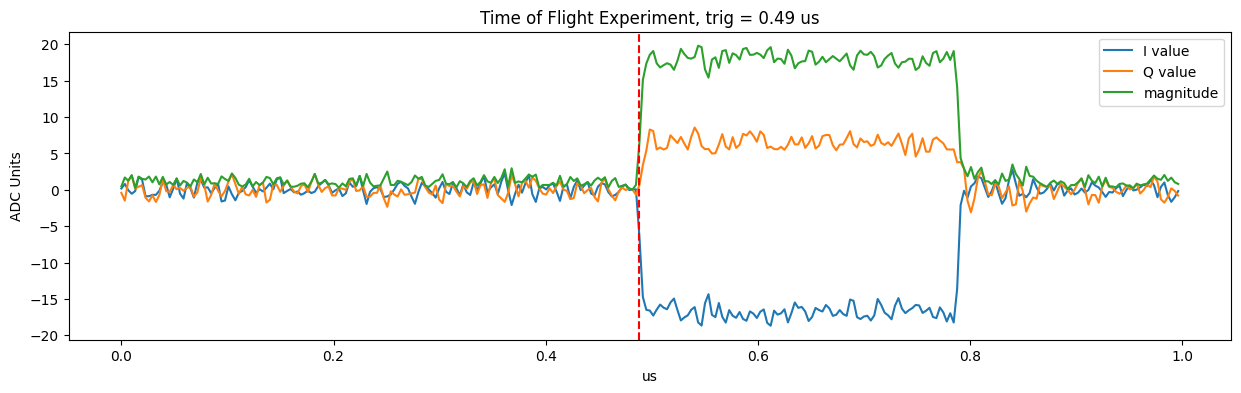

In [9]:
# Plot results.
mean=np.mean(np.abs(iq_list[0].dot([1,1j])))


plt.figure(figsize=(15,4))
plt.plot(t, iq_list[0][:,0], label="I value")
plt.plot(t, iq_list[0][:,1], label="Q value")
plt.plot(t, np.abs(iq_list[0].dot([1,1j])), label="magnitude")
plt.legend()
plt.ylabel("ADC Units")
plt.xlabel("us")

######## SET THIS VALUE AS YOUR config['trig_time'] #########
# plt.axvline(0.5, c='r') 
plt.axvline(t[np.argmax(np.abs(iq_list[0].dot([1,1j]))> 0.7*mean)], c='r', ls='--')
plt.title(f'Time of Flight Experiment, trig = {round(t[np.argmax(np.abs(iq_list[0].dot([1,1j]))> 0.7*mean)],2)} us')
config['trig_time'] = round(t[np.argmax(np.abs(iq_list[0].dot([1,1j]))> 0.7*mean)],2)

# Resonator Spectroscopy

In [554]:
## Using the Dynamically Configured Readout Channel ##
class SingleToneSpectroscopyProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        
        self.declare_gen(ch=res_ch, nqz=2)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])
        loopbefore  = AsmV2()
        loopbefore.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        self.add_loop("freqloop", cfg["steps"], exec_before=loopbefore)
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)
        
        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch, 
                       style="const", 
                       length=100, 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )
        

    def _body(self, cfg):
        # self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])


In [576]:

center = r[qubit_idx]
START_FREQ = center - 50 # [MHz]
STOP_FREQ =  center + 50 # [MHz]
STEPS = 101

exp_cfg = {
    'steps': STEPS, # Number of sweep points
    'f_res': QickSweep1D('freqloop', START_FREQ, STOP_FREQ), # [MHz]
    'res_gain': 0.12
}
run_cfg = {**config, **exp_cfg}


  0%|          | 0/10 [00:00<?, ?it/s]

{'Fres(GHz)': 5797563429.533,
 'Qi': 12376,
 'Ql': 357,
 'absQc': 368,
 'κ(MHz)': 16.24}


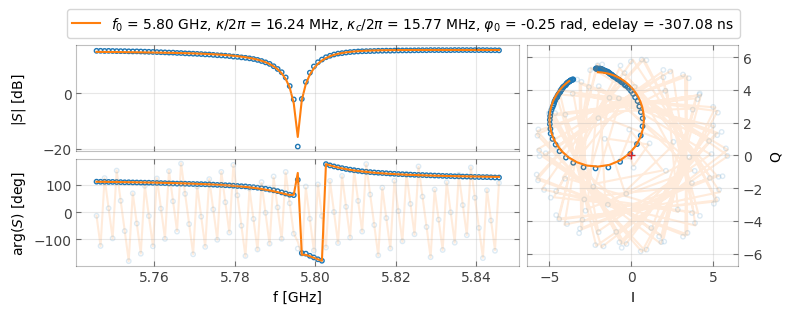

In [577]:
pyavg = 10

prog = SingleToneSpectroscopyProgram(soccfg, reps=100, final_delay=1, cfg=run_cfg)
iq_list = prog.acquire(soc, soft_avgs=pyavg, progress=True)
freqs = prog.get_pulse_param("res_pulse", "freq", as_array=True)
res_onetone = (iq_list[0][0].dot([1,1j]))

fit = resonator_circlefit(freqs, res_onetone)
f_res = round(fit[0]/1e6, 3)
config['f_res'] = f_res

In [578]:
data_path = data_path
exp_name = f"R{qubit_idx+1} resonator spec"


file_path = get_next_filename_labber(data_path, exp_name)
hdf5_generator(
        filepath=file_path,
        x_info={'name': 'Frequency', 'unit': "Hz",
                'values': freqs*1e6},  

        z_info={'name': 'Signal', 'unit': 'a.u.',
                'values':  res_onetone},
        comment=(f'f_res = {f_res:.3f} MHz\
                 \nYoko = {yoko_connect} mA'),
        tag= 'OneTone'
)

# Resonator Onetone Flux

  0%|          | 0/41 [00:00<?, ?it/s]

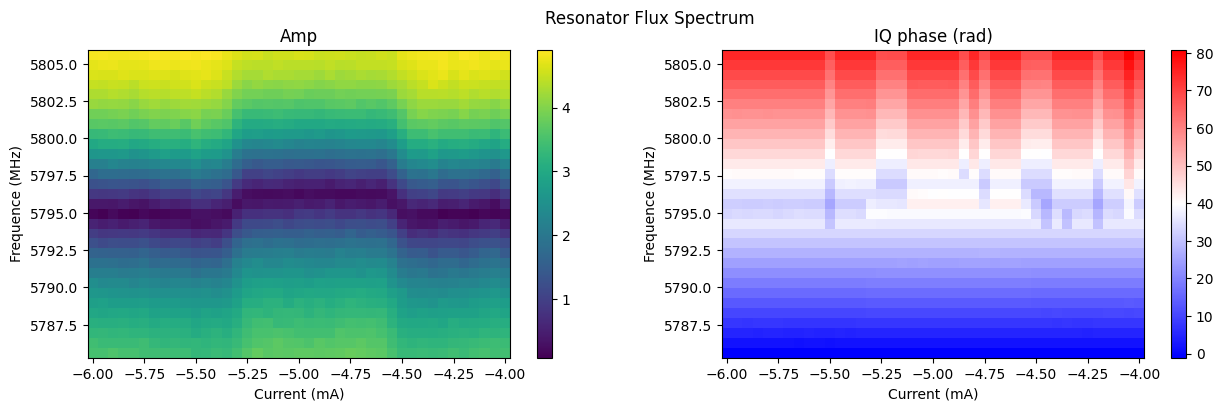

In [18]:

START_FREQ = r[qubit_idx]-10 # [MHz]
STOP_FREQ = r[qubit_idx]+10 # [MHz]
STEPS = 31

Start_flux = -6 # [mA]
Stop_flux = -4 # [mA]
Steps_flux = 41

pyavg = 20


### Flux array ###
flux = np.linspace(Start_flux, Stop_flux, Steps_flux)*1e-3
exp_cfg = {
    'steps': STEPS, # Number of sweep points
    'f_res': QickSweep1D('freqloop', START_FREQ, STOP_FREQ), # [MHz]
    'res_gain': 0.123
}
run_cfg = {**config, **exp_cfg}

z=[]
for i in tqdm(flux):
    yoko_global.setValue(sQuant='Current', value=i, rate=20e-6)
    prog = SingleToneSpectroscopyProgram(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
    iq_list = prog.acquire(soc, soft_avgs=pyavg, progress=False)
    z.append(iq_list[0][0].dot([1,1j]))

freqs = prog.get_pulse_param("res_pulse", "freq", as_array=True)

avg_abs, avg_angle = np.abs(z), np.angle(z)

fig, axes = plt.subplots(1, 2, figsize=(15,4))
fig.suptitle('Resonator Flux Spectrum')
for i, d in enumerate([avg_abs, avg_angle]):
    if i==0:
        pcm = axes[i].pcolormesh(flux*1e3, freqs, d.T, shading="Auto")
    else:
        pcm = axes[i].pcolormesh(flux*1e3, freqs, np.unwrap(d).T, shading="Auto", cmap="bwr")
    axes[i].set_ylabel("Frequence (MHz)")
    axes[i].set_xlabel("Current (mA)")
    axes[i].set_title("Amp" if i ==0  else "IQ phase (rad)")
    plt.colorbar(pcm, ax=axes[i])

In [19]:
data_path = data_path
exp_name = f"R{qubit_idx+1} resonator flux spec"


file_path = get_next_filename_labber(data_path, exp_name)

hdf5_generator(
        filepath=file_path,
        x_info={'name': 'Frequency', 'unit': "Hz",
                'values': freqs*1e6},
        y_info={'name': 'Flux', 'unit': "A",
                'values': flux},
        z_info={'name': 'Signal', 'unit': 'a.u.',
                'values':  np.array(z)},
        comment=f'',
        tag='OneTone'
)

# Resonator Punch out

In [ ]:
class SingleTonePunchoutProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        
        self.declare_gen(ch=res_ch, nqz=2)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        self.add_loop("gainloop", cfg["g_steps"])
        self.add_loop("freqloop", cfg["f_steps"])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)
        
        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch,
                       style="const",
                       length=cfg['res_len'], 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )

    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

In [ ]:
res_idx=0
center = r[res_idx]
START_FREQ = center - 20 # [MHz]
STOP_FREQ = center + 20 # [MHz]
STEPS_freq = 81

START_gain = 0.002 # [au]
STOP_gain = 0.3 # [au]
STEPS_gain = 51


expt_cfg = {
    ## Sweep Params: ##
    'f_steps': STEPS_freq, 
    'g_steps': STEPS_gain, 

    ## Resonator Pulse Params. ##
    'f_res': QickSweep1D('freqloop', START_FREQ, STOP_FREQ), # [MHz]
    'res_gain': QickSweep1D('gainloop', START_gain, STOP_gain), # [DAC units]
     }
run_cfg = {**config, **expt_cfg}

In [ ]:
pyavg = 50

prog = SingleTonePunchoutProgram(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
iq_list = prog.acquire(soc, soft_avgs=pyavg, progress=True)
freqs = prog.get_pulse_param("res_pulse", "freq", as_array=True)
gains = prog.get_pulse_param("res_pulse", "gain", as_array=True)
res_punchout = iq_list[0][0].dot([1,1j])


avg_abs, avg_angle = np.abs(res_punchout), np.angle(res_punchout)

plt.figure( figsize=(15,4))
plt.title('Resonaotr Punch Out')
plt.pcolormesh(freqs, gains, avg_abs, shading="Auto")
plt.ylabel("DAC Gain")
plt.xlabel("Frequence (MHz)")
plt.title("Amp")
plt.colorbar()

In [ ]:
data_path = data_path
exp_name = f"R{qubit_idx+1} res punch out"


file_path = get_next_filename_labber(data_path, exp_name)

hdf5_generator(
        filepath=file_path,
        x_info={'name': 'Frequency', 'unit': "Hz",
                'values': freqs*1e6},  
        y_info={'name': 'DAC Gain', 'unit': "a.u",
                'values': gains},
        z_info={'name': 'Signal', 'unit': 'a.u.',
                'values':  iq_list[0][0].dot([1,1j])},
        comment=f'',
        tag='OneTone'
)

# Qubit Spec

In [11]:
class PulseProbeSpectroscopyProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        qubit_ch = cfg['qubit_ch']
        
        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][qubit_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'], mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'])
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        self.add_loop("freqloop", cfg["steps"])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)

        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch,
                       style="const",
                       length=cfg['res_len'], 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )

        self.add_pulse(ch=qubit_ch, name="qubit_pulse",
                       style="const", 
                       length=cfg['probe_len'], 
                       freq=cfg['f_ge'], 
                       phase= 0,
                       gain=cfg['qubit_gain'],
                      )

    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        self.pulse(ch=self.cfg["qubit_ch"], name="qubit_pulse", t=0)
        self.delay_auto(t=0.05, tag='wait')
        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

In [852]:
cemter = 350

START_FREQ = cemter - 200# [MHz]
STOP_FREQ = cemter + 200  # [MHz]
STEPS = 200
config.update({'qmixer_freq':cemter, 'qubit_gain':0.05, 'qubit_ch':11, 'res_gain':0.1, 'nqz':1})
expt_cfg = {
    ## Sweep Params: ##
    'steps': STEPS, # Number of sweep points
    ## Qubit Params. ##
    'f_ge': QickSweep1D('freqloop', START_FREQ, STOP_FREQ), # [MHz]
     }

run_cfg = {**config, **expt_cfg}
run_cfg['res_len'] = 10
run_cfg['ro_len'] = 10

  0%|          | 0/50 [00:00<?, ?it/s]

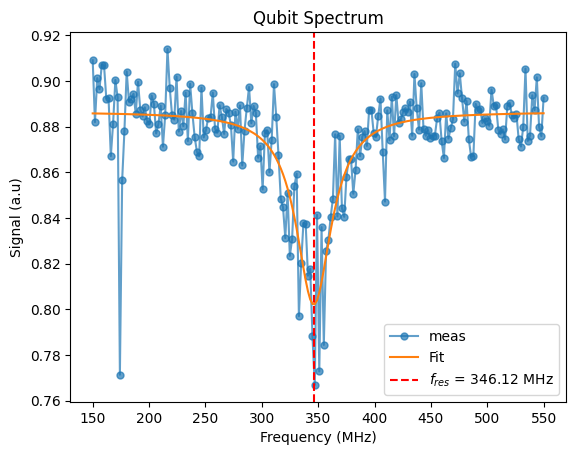

In [853]:
pyavg = 50
qspec=PulseProbeSpectroscopyProgram(soccfg, reps=100, final_delay=1, cfg=run_cfg)
iq_list = qspec.acquire(soc, soft_avgs=pyavg, progress=True)
freqs = qspec.get_pulse_param('qubit_pulse', "freq", as_array=True)

f_q = spectrum_analyze(freqs, np.abs(iq_list[0][0].dot([1,1j])))
config['f_ge'] = round(f_q, 3)
config['qmixer_freq']= round(f_q,3)

In [581]:
data_path = data_path
exp_name = f"q{qubit_idx+1} qubit spec"

run_cfg.pop('f_ge')
dict_val = yml_comment(run_cfg)

file_path = get_next_filename_labber(data_path, exp_name)
hdf5_generator(
        filepath=file_path,
        x_info={'name': 'Frequency', 'unit': "Hz",
                'values': freqs*1e3},
        z_info={'name': 'Signal', 'unit': 'a.u.',
                'values':  iq_list[0][0].dot([1,1j])},
        comment=(f'f_q = {f_q} MHz\
                 \nYoko = {Yoko_current} mA\
                 \n{run_cfg["res_gain"]}, qb_gain={run_cfg["qubit_gain"]}\
                 \n\n{dict_val}'),
        tag='TwoTone')

# Qubit Flux Spec

  0%|          | 0/21 [00:00<?, ?it/s]

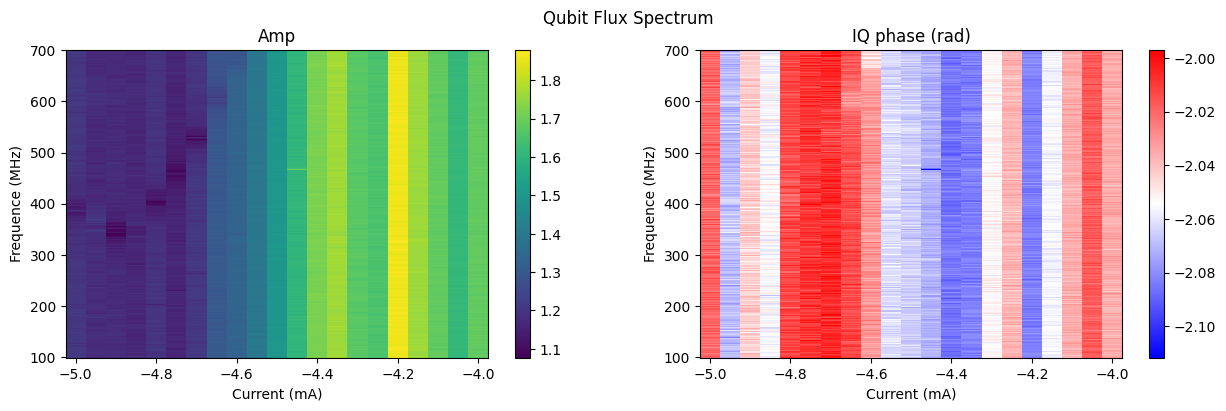

In [573]:
Start_flux = -5 # [mA]
Stop_flux = -4 # [mA]
Steps = 21

cemter = 400

START_FREQ = cemter - 300# [MHz]
STOP_FREQ = cemter + 300  # [MHz]
STEPS = 300
config.update({'qmixer_freq':cemter,'qubit_gain': 0.1, 'res_gain':0.1})
expt_cfg = {
    ## Sweep Params: ##
    'steps': STEPS, # Number of sweep points
    ## Qubit Params. ##
    'f_ge': QickSweep1D('freqloop', START_FREQ, STOP_FREQ), # [MHz]
     }

run_cfg = {**config, **expt_cfg}
pyavg = 100


### Flux array ###
flux = np.linspace(Start_flux, Stop_flux, Steps)*1e-3

z=[]
for i in tqdm(flux):
    yoko_global.setValue(sQuant='Current', value=i, rate=10e-6)
    qspec=PulseProbeSpectroscopyProgram(soccfg, reps=100, final_delay=1, cfg=run_cfg)
    iq_list = qspec.acquire(soc, soft_avgs=pyavg, progress=False)
    qb_spec = iq_list[0][0].dot([1,1j])
    z.append(qb_spec)

freqs = qspec.get_pulse_param('qubit_pulse', "freq", as_array=True)


avg_abs, avg_angle = np.abs(z), np.angle(z)

fig, axes = plt.subplots(1, 2, figsize=(15,4))
fig.suptitle('Qubit Flux Spectrum')
for i, d in enumerate([avg_abs, avg_angle]):
    if i==0:
        pcm = axes[i].pcolormesh(flux*1e3, freqs, d.T, shading="Auto")
    else:
        pcm = axes[i].pcolormesh(flux*1e3, freqs, np.unwrap(d).T, shading="Auto", cmap="bwr")
    axes[i].set_ylabel("Frequence (MHz)")
    axes[i].set_xlabel("Current (mA)")
    axes[i].set_title("Amp" if i ==0  else "IQ phase (rad)")
    plt.colorbar(pcm, ax=axes[i])

In [574]:
data_path = data_path
exp_name = f"q{qubit_idx+1} qubit flux spec"


file_path = get_next_filename_labber(data_path, exp_name)

hdf5_generator(
        filepath=file_path,
        x_info={'name': 'Frequency', 'unit': "Hz",
                'values': freqs*1e6},  
        y_info={'name': 'Flux', 'unit': "A",
                'values': flux},
        z_info={'name': 'Signal', 'unit': 'a.u.',
                'values':  np.array(z)},
                
        comment=f'',
        tag='TwoTone'
)

# Length Rabi

In [29]:
class LengthRabiProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        qubit_ch = cfg['qubit_ch']
        
        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][qubit_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'], mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'])
        # pynq configured
        # self.declare_readout(ch=ro_ch, length=cfg['ro_len'], freq=cfg['f_res'], gen_ch=res_ch)
        
        # tproc configured
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)
        
        self.add_pulse(ch=res_ch, name="res_pulse", 
                       style="const", 
                       length=cfg['res_len'], 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )
        self.add_gauss(ch=qubit_ch, name="ramp", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
        if cfg['qb_pulse_style']=='arb':
            self.add_pulse(ch=qubit_ch, name="qubit_pulse", 
                        style="arb", 
                        envelope="ramp", 
                        freq=cfg['f_ge'], 
                        phase= cfg['qubit_phase'],
                        gain=cfg['qubit_gain'],
                        )
        elif cfg['qb_pulse_style']=='flat_top':
            self.add_pulse(ch=qubit_ch, name="qubit_pulse", 
                           style="flat_top", 
                           envelope="ramp", 
                           freq=cfg['f_ge'], 
                           phase= cfg['qubit_phase'],
                           gain=cfg['qubit_gain'],
                           length = cfg['flat_top_len']
                          )
    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        self.pulse(ch=cfg["qubit_ch"], name="qubit_pulse", t=0)  #play probe pulse

        self.delay_auto(t=0.05, tag='waiting')
        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

  0%|          | 0/51 [00:00<?, ?it/s]

(0.034, 0.008)

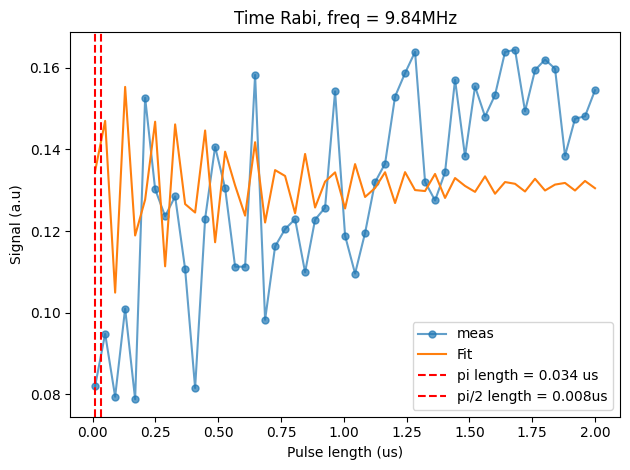

In [ ]:
length=np.linspace(0.01, 0.05, 51) # [us]
run_cfg['f_ge'] = config['f_ge']
pyavg = 50
amp=[]

for i in tqdm(length):
    run_cfg['sigma']=i
    run_cfg['qubit_gain'] = 0.8
    prog = LengthRabiProgram(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
    iq_list = prog.acquire(soc, soft_avgs=pyavg, progress=False)
    amp.append(iq_list[0][0].dot([1,1j]))

lengthrabi_analyze(length, np.abs(amp))

In [510]:
data_path = data_path
exp_name = f"q{qubit_idx+1} length rabi"


file_path = get_next_filename_labber(data_path, exp_name)
hdf5_generator(
        filepath=file_path,
        x_info={'name': 'Time', 'unit': "s",
                'values': length*1e-6},
        z_info={'name': 'Signal', 'unit': 'a.u.',
                'values': np.array(amp)},
        comment=f'relax = {run_cfg["relax_delay"]} us, \n{run_cfg}',
        tag='Rabi')

# Power Rabi

In [582]:
class AmplitudeRabiProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        qubit_ch = cfg['qubit_ch']
        
        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][qubit_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'], mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'])
        # pynq configured
        # self.declare_readout(ch=ro_ch, length=cfg['ro_len'], freq=cfg['f_res'], gen_ch=res_ch)
        
        # tproc configured
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)

        self.add_loop("gainloop", cfg["steps"])

        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch, 
                       style="const",
                       length=cfg['res_len'], 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )
        
        self.add_gauss(ch=qubit_ch, name="ramp", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
        if cfg['qb_pulse_style']=='arb':
            self.add_pulse(ch=qubit_ch, name="qubit_pulse", 
                        style="arb", 
                        envelope="ramp", 
                        freq=cfg['f_ge'], 
                        phase= cfg['qubit_phase'],
                        gain=cfg['qubit_gain'],
                        )
        elif cfg['qb_pulse_style']=='flat_top':
            self.add_pulse(ch=qubit_ch, name="qubit_pulse", 
                           style="flat_top", 
                           envelope="ramp", 
                           freq=cfg['f_ge'], 
                           phase= cfg['qubit_phase'],
                           gain=cfg['qubit_gain'],
                           length = cfg['flat_top_len']
                          )
        
    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        if self.cfg['rabi_protocal'] == 'pi':
            self.pulse(ch=cfg["qubit_ch"], name="qubit_pulse", t=0)  #play probe pulse
        elif self.cfg['rabi_protocal'] == 'pipi':
            self.pulse(ch=cfg["qubit_ch"], name="qubit_pulse", t=0)  
            self.delay_auto(0.0)
            self.pulse(ch=cfg["qubit_ch"], name="qubit_pulse", t=0)
            self.delay_auto(0.0)

        self.delay_auto(t=0.05, tag='waiting')
        self.pulse(ch=cfg['res_ch'], name="res_pulse", t = 0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

In [610]:
START_GAIN = 0.0 # [DAC units]
STOP_GAIN = 1 # [DAC units]
STEPS = 50


config.update({'relax_delay':150, 'qb_pulse_style':'arb', 'sigma':0.005, 'flat_top_len':0.1, 'nqz':1})
expt_cfg = {
    ## Sweep Params: ##
    'steps': STEPS, # Number of sweep points
    'qmixer_freq':config['f_ge'],
    "qubit_gain": QickSweep1D('gainloop', START_GAIN, STOP_GAIN), # [DAC units]
    'rabi_protocal': 'pi',
     }
run_cfg = {**config, **expt_cfg}

  0%|          | 0/100 [00:00<?, ?it/s]

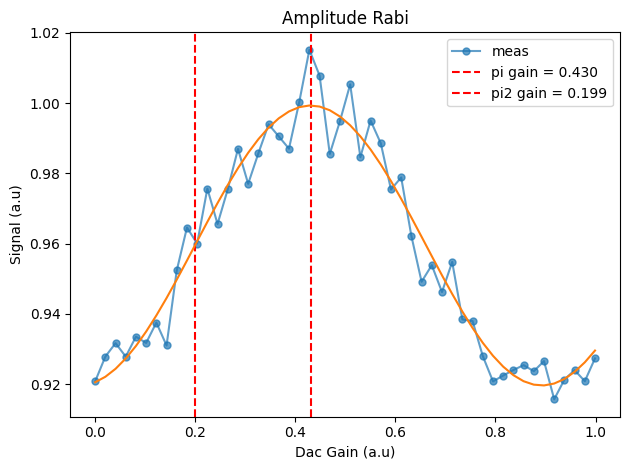

In [595]:
pyavg = 100
run_cfg['rabi_protocal']='pi'
amp_rabi=AmplitudeRabiProgram(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
iq_list = amp_rabi.acquire(soc, soft_avgs=pyavg, progress=True, threshold=run_cfg['thresholds'])
gains = amp_rabi.get_pulse_param('qubit_pulse', "gain", as_array=True)
power_rabi = iq_list[0][0].dot([1,1j])
config['pi_gain'], config['pi2_gain'] = amprabi_analyze(gains, (iq_list[0][0].dot([1,1j])), protocal=None)

In [589]:
data_path = data_path
exp_name = f"q{qubit_idx+1} power rabi"


file_path = get_next_filename_labber(data_path, exp_name)
hdf5_generator(
        filepath=file_path,
        x_info={'name': 'DAC Gain', 'unit': "a.u",
                'values': gains},
        z_info={'name': 'Signal', 'unit': 'a.u.',
                'values':  iq_list[0][0].dot([1,1j])},
        comment=f'relax={run_cfg["relax_delay"]}, at {Yoko_current}mA\
                \n\n{run_cfg}',
        tag='Rabi')

## Fine Tune Power Rabi

In [601]:
START_GAIN = 0.0 # [DAC units]
STOP_GAIN = 1 # [DAC units]
STEPS = 100


config.update({'relax_delay':100, 'qb_pulse_style':'arb', 'sigma':0.005, 'flat_top_len':0.5})
expt_cfg = {
    ## Sweep Params: ##
    'steps': STEPS, # Number of sweep points
    'qmixer_freq':config['f_ge'],
    "qubit_gain":QickSweep1D('gainloop', START_GAIN, STOP_GAIN), # [DAC units]
    'rabi_protocal': 'pi',
     }
run_cfg = {**config, **expt_cfg}

  0%|          | 0/150 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]

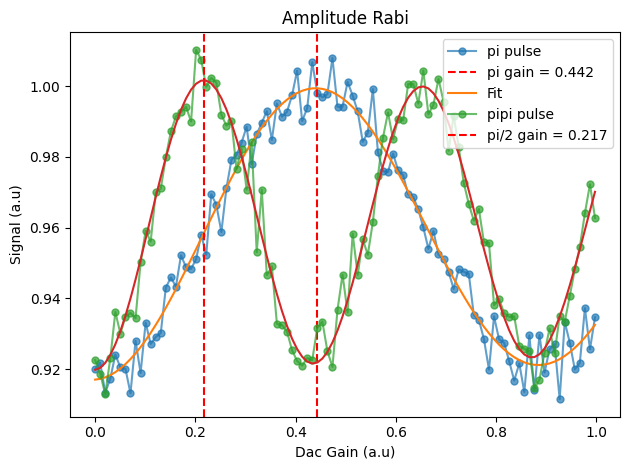

In [602]:
pyavg = 150
run_cfg = {**config, **expt_cfg}

run_cfg['rabi_protocal']='pi'
amp_rabi=AmplitudeRabiProgram(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
iq_list = np.array(amp_rabi.acquire(soc, soft_avgs=pyavg, progress=True))
gains = amp_rabi.get_pulse_param('qubit_pulse', "gain", as_array=True)
power_rabi = iq_list[0][0].dot([1,1j])
config['pi_gain'], _ = amprabi_analyze(gains, np.abs(iq_list[0][0].dot([1,1j])), protocal=run_cfg['rabi_protocal'])

run_cfg['rabi_protocal']='pipi'
amp_rabi=AmplitudeRabiProgram(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
iq_list = np.array(amp_rabi.acquire(soc, soft_avgs=pyavg, progress=True))
gains = amp_rabi.get_pulse_param('qubit_pulse', "gain", as_array=True)
power_rabi2 = iq_list[0][0].dot([1,1j])
config['pi2_gain'], _ = amprabi_analyze(gains, np.abs(iq_list[0][0].dot([1,1j])), protocal=run_cfg['rabi_protocal'])

In [603]:
data_path = data_path
exp_name = f"q{qubit_idx+1} power rabi fine tune"

try:
    run_cfg.pop('qubit_gain')
except:
    pass
dict_val = yml_comment(run_cfg)
file_path = get_next_filename_labber(data_path, exp_name)
hdf5_generator(
        filepath=file_path,
        x_info={'name': 'DAC Gain', 'unit': "a.u",
                'values': gains},
        y_info={'name': '# pi pulse ', 'unit': "#",
                'values': [1,2]},
        z_info={'name': 'Signal', 'unit': 'a.u.',
                'values':  np.array([power_rabi, power_rabi2])},
        comment=f'relax={run_cfg["relax_delay"]}, at {Yoko_current}mA\
                \n\n{dict_val}',
        tag='Rabi')

# Ramsey Fringe Experiment

In [515]:
class RamseyProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        qubit_ch = cfg['qubit_ch']
        
        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][qubit_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'], mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'])
        # pynq configured
        # self.declare_readout(ch=ro_ch, length=cfg['ro_len'], freq=cfg['f_res'], gen_ch=res_ch)
        
        # tproc configured
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)
        
        self.add_loop("waitloop", cfg["steps"])
        
        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch, 
                       style="const",
                       length=cfg['res_len'], 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )
        
        self.add_gauss(ch=qubit_ch, name="ramp", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
        if cfg['qb_pulse_style']=='arb':
            self.add_pulse(ch=qubit_ch, name="qubit_pulse1", ro_ch=ro_ch,
                        style="arb",
                        envelope="ramp",
                        freq=cfg['f_ge'],
                        phase=cfg['qubit_phase'],
                        gain=cfg['pi2_gain'],
                        )

            self.add_pulse(ch=qubit_ch, name="qubit_pulse2",ro_ch=ro_ch,
                        style="arb",
                        envelope="ramp",
                        freq=cfg['f_ge'],
                        phase=cfg['qubit_phase'] + cfg['wait_time']*360*cfg['ramsey_freq'],
                        gain=cfg['pi2_gain'],
                        )
        elif cfg['qb_pulse_style']=='flat_top':
            self.add_pulse(ch=qubit_ch, name="qubit_pulse1",ro_ch=ro_ch,
                        style="flat_top",
                        envelope="ramp", 
                        length = cfg['flat_top_len'],
                        freq=cfg['f_ge'],
                        phase= cfg['qubit_phase'],
                        gain=cfg['pi2_gain'],
                        )
            self.add_pulse(ch=qubit_ch, name="qubit_pulse2",ro_ch=ro_ch,
                        style="flat_top",
                        envelope="ramp",
                        length = cfg['flat_top_len'],
                        freq=cfg['f_ge'],
                        phase=cfg['qubit_phase'] + cfg['wait_time']*360*cfg['ramsey_freq'],
                        gain=cfg['pi2_gain'],
                        )
    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        self.pulse(ch=self.cfg["qubit_ch"], name="qubit_pulse1", t=0)  
        
        self.delay_auto(cfg['wait_time'], tag='wait') 
        
        self.pulse(ch=self.cfg["qubit_ch"], name="qubit_pulse2", t=0)  

        self.delay_auto(0.05) 
        
        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0) 
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

In [590]:
START_TIME = 0. # [us]
STOP_TIME = 5 # [us]
STEPS = 150

expt_cfg = {
    ## Sweep Params: ##
    'steps': STEPS, # Number of sweep points
    'wait_time': QickSweep1D('waitloop', START_TIME, STOP_TIME), # [us]
    'ramsey_freq':2,
    }

run_cfg = {**config, **expt_cfg}


  0%|          | 0/100 [00:00<?, ?it/s]

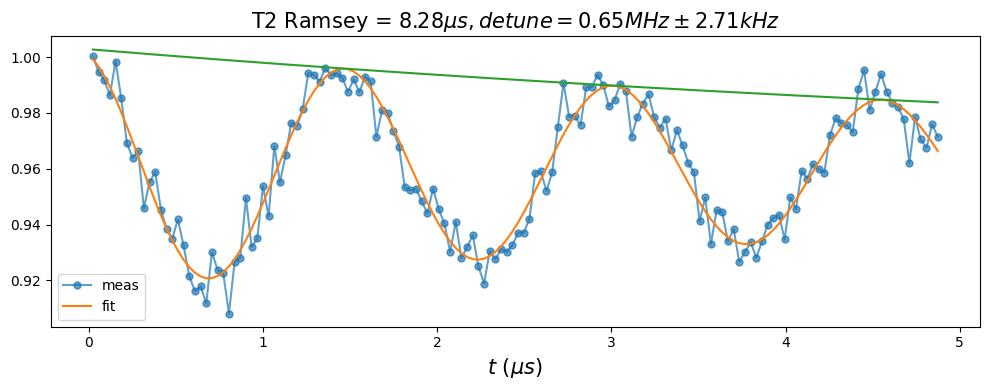

In [591]:
pyavg = 100

ramsey=RamseyProgram(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
iq_list = ramsey.acquire(soc, soft_avgs=pyavg, progress=True, threshold=run_cfg['thresholds'])
delay_times = ramsey.get_time_param('wait', "t", as_array=True)
ramsey = iq_list[0][0].dot([1,1j])

t2r = T2fring_analyze(delay_times, (ramsey), prefix='Ramsey')

In [592]:
activate_correct=True
if activate_correct:
    if abs(t2r[1]-run_cfg['ramsey_freq'])>0.05:
        config['f_ge'] = config['f_ge']-round((t2r[1]-run_cfg['ramsey_freq']),3)
        print(f'over detune {round((t2r[1]-run_cfg["ramsey_freq"]),3)}')
        print('Correct')
    else:
        print(f'over detune {round((t2r[1]-run_cfg["ramsey_freq"]),3)}')

over detune -1.352
Correct


In [593]:
data_path = data_path
exp_name = f"q{qubit_idx+1} T2 Ramsey "

try:
        run_cfg.pop('wait_time')
except:
        pass

dict_val = yml_comment(run_cfg)

file_path = get_next_filename_labber(data_path, exp_name)
hdf5_generator(
        filepath=file_path,
        x_info={'name': 'Time', 'unit': "s",
                'values': delay_times*1e-6},
        z_info={'name': 'Signal', 'unit': 'a.u.',
                'values':  iq_list[0][0].dot([1,1j])},
        comment=(f'Detune = {t2r[1]-run_cfg["ramsey_freq"]:.2f} MHz\
                \nRamsey Frequency =  {run_cfg["ramsey_freq"]:.2f}\
                \nT2R = {t2r[3]:.2f}us\
                \nYokogawa = {yoko_connect}mA\
                \n\n{dict_val}'),
        tag='T2')

RepresenterError: cannot represent an object: <qick.asm_v2.QickParam object at 0x00000216EA42EAC0>

# Spin Echo Experiment

In [ ]:
class SpinEchoProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        qubit_ch = cfg['qubit_ch']
        
        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][qubit_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'], mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'])
        # pynq configured
        # self.declare_readout(ch=ro_ch, length=cfg['ro_len'], freq=cfg['f_res'], gen_ch=res_ch)

        # tproc configured
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)

        self.add_loop("waitloop", cfg["steps"])

        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch,
                       style="const",
                       length=cfg['res_len'],
                       freq=cfg['f_res'],
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )

        self.add_gauss(ch=qubit_ch, name="ramp", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
        if cfg['qb_pulse_style']=='arb':
            self.add_pulse(ch=qubit_ch, name="qubit_pulse1",
                        style="arb",
                        envelope="ramp",
                        freq=cfg['f_ge'],
                        phase=cfg['qubit_phase'],
                        gain=cfg['pi2_gain'],
                        )
            self.add_pulse(ch=qubit_ch, name="qubit_pulse_pi",
                        style="arb",
                        envelope="ramp",
                        freq=cfg['f_ge'],
                        phase=cfg['qubit_phase'],
                        gain=cfg['pi_gain'],
                        )
            self.add_pulse(ch=qubit_ch, name="qubit_pulse2",
                        style="arb", 
                        envelope="ramp", 
                        freq=cfg['f_ge'], 
                        phase=cfg['qubit_phase']+ cfg['wait_time']*360*cfg['ramsey_freq'], 
                        gain=cfg['pi2_gain'], 
                        )
        elif cfg['qb_pulse_style']=='flat_top':
            self.add_pulse(ch=qubit_ch, name="qubit_pulse_pi", 
                           style="flat_top", 
                           envelope="ramp", 
                           length = cfg['flat_top_len'], 
                           freq=cfg['f_ge'], 
                           phase= cfg['qubit_phase'],
                           gain=cfg['pi_gain'],
                          )
            self.add_pulse(ch=qubit_ch, name="qubit_pulse1", 
                           style="flat_top", 
                           envelope="ramp", 
                           length = cfg['flat_top_len'],
                           freq=cfg['f_ge'], 
                           phase= cfg['qubit_phase'],
                           gain=cfg['pi2_gain'],
                          )
            self.add_pulse(ch=qubit_ch, name="qubit_pulse2", 
                           style="flat_top", 
                           envelope="ramp", 
                           length = cfg['flat_top_len'],
                           freq=cfg['f_ge'], 
                           phase=cfg['qubit_phase'] + cfg['wait_time']*360*cfg['ramsey_freq'], 
                           gain=cfg['pi2_gain'],
                          )
    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        self.pulse(ch=cfg["qubit_ch"], name="qubit_pulse1", t=0)  #play pulse
        
        self.delay_auto((cfg['wait_time']/2)+0.01, tag = 'wait1') # wait_time after last pulse (wait / 2)
        
        self.pulse(ch=self.cfg["qubit_ch"], name="qubit_pulse_pi", t=0)  #play pulse
        
        self.delay_auto((cfg['wait_time']/2)+0.01, tag = 'wait2') # wait_time after last pulse (wait / 2)

        self.pulse(ch=self.cfg["qubit_ch"], name="qubit_pulse2", t=0)  #play pulse

        self.delay_auto(0.01) # wait_time after last pulse
        
        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0) # play probe pulse
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

In [618]:
START_TIME = 0.0 # [us]
STOP_TIME = 20 # [us]
STEPS = 150

expt_cfg = {
    ## Sweep Params: ##
    'steps': STEPS, # Number of sweep points
    'ramsey_freq':0.4,
    'wait_time': QickSweep1D('waitloop', START_TIME, STOP_TIME), # [us]
    }

run_cfg = {**config, **expt_cfg}


  0%|          | 0/150 [00:00<?, ?it/s]

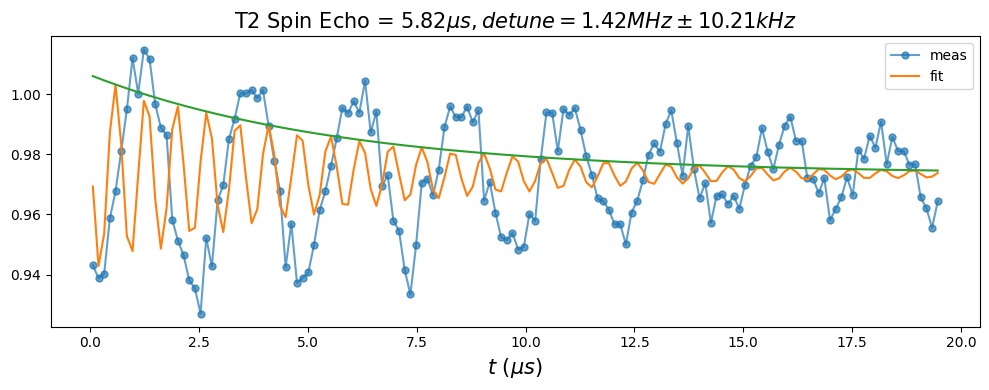

In [619]:
pyavg = 150

spinecho=SpinEchoProgram(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
iq_list = spinecho.acquire(soc, soft_avgs=pyavg, progress=True, threshold=run_cfg['thresholds'])
delay_times1 = spinecho.get_time_param('wait1', "t", as_array=True)
delay_times2 = spinecho.get_time_param('wait2', "t", as_array=True)
spinecho = iq_list[0][0].dot([1,1j])

t2e = T2fring_analyze(delay_times1+delay_times2, spinecho,  prefix='Spin Echo')

array([4.10030686e-02, 4.10457426e-01, 2.69191323e+02, 1.65537266e+01,
       9.72622446e-01])

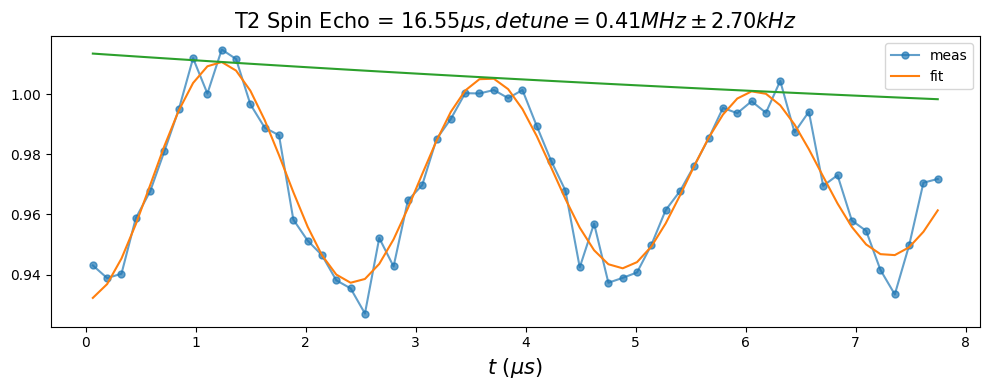

In [622]:
T2fring_analyze((delay_times1+delay_times2)[:60], spinecho[:60],  prefix='Spin Echo')

In [613]:
data_path = data_path
exp_name = f"q{qubit_idx+1} T2 SpinEcho "

try:
        run_cfg.pop('wait_time')
except:
        pass

dict_val = yml_comment(run_cfg)

file_path = get_next_filename_labber(data_path, exp_name)
hdf5_generator(
        filepath=file_path,
        x_info={'name': 'Time', 'unit': "s",
                'values': (delay_times1+delay_times2)*1e-6},
        z_info={'name': 'Signal', 'unit': 'a.u.',
                'values':  iq_list[0][0].dot([1,1j])},
        comment=(f'detune = {t2e[1]-run_cfg["ramsey_freq"]:.2f} MHz\
                \nRamsey Frequency =  {run_cfg["ramsey_freq"]:.2f}\
                \nT2E = {t2e[3]:.2f}us\
                \nYokogawa = {-4.2}mA\
                \n\n{dict_val}'),
        tag='T2')

# T1

In [528]:
class T1Program(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        qubit_ch = cfg['qubit_ch']
        
        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][qubit_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'], mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'])
        # pynq configured
        # self.declare_readout(ch=ro_ch, length=cfg['ro_len'], freq=cfg['f_res'], gen_ch=res_ch)
        
        # tproc configured
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)

        self.add_loop("waitloop", cfg["steps"])
        self.add_gauss(ch=res_ch, name="res", sigma=0.01, length=0.01*5, even_length=True)
        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch, 
                       style="flat_top",
                       envelope='res',
                       length=cfg['res_len'], 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )
        
        self.add_gauss(ch=qubit_ch, name="ramp", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
        if cfg['qb_pulse_style']=='arb':
            self.add_pulse(ch=qubit_ch, name="qubit_pulse", ro_ch=ro_ch, 
                        style="arb", 
                        envelope="ramp", 
                        freq=cfg['f_ge'],
                        phase=cfg['qubit_phase'],
                        gain=cfg['pi_gain'], 
                        )
        elif cfg['qb_pulse_style']=='flat_top':
            self.add_pulse(ch=qubit_ch, name="qubit_pulse", ro_ch=ro_ch, 
                           style="flat_top", 
                           envelope="ramp", 
                           length = cfg['flat_top_len'],
                           freq=cfg['f_ge'], 
                           phase= cfg['qubit_phase'],
                           gain=cfg['pi_gain'],
                          )

    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        self.pulse(ch=self.cfg["qubit_ch"], name="qubit_pulse", t=0)  #play pulse

        self.delay_auto(cfg['wait_time']+0.05, tag='wait') # wait_time after last pulse

        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0) # play probe pulse
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

In [607]:
START_TIME = 0.0 # [us]
STOP_TIME = 100.0 # [us]
STEPS = 50

expt_cfg = {
    ## Sweep Params: ##
    'steps': STEPS, # Number of sweep points
    'wait_time': QickSweep1D('waitloop', START_TIME, STOP_TIME), # [us]
    'relax_delay': 100,
    }

run_cfg = {**config, **expt_cfg}

  0%|          | 0/100 [00:00<?, ?it/s]

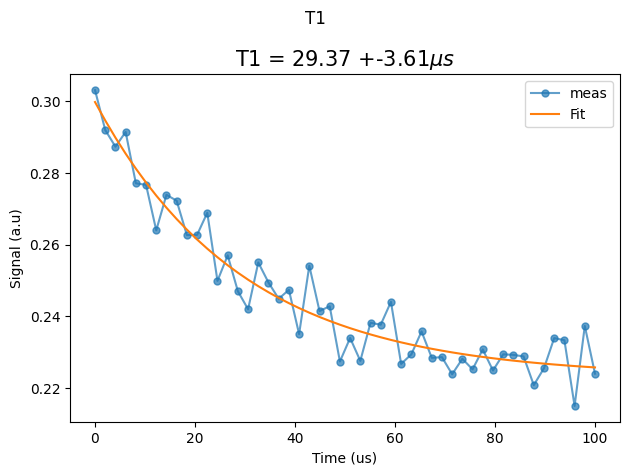

In [608]:
pyavg = 100
T1=T1Program(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
iq_list = T1.acquire(soc, soft_avgs=pyavg, progress=True, threshold=run_cfg['thresholds'])
delay_times = T1.get_time_param('wait', "t", as_array=True)

t1 = T1_analyze(delay_times, (iq_list[0][0].dot([1,1j])))

In [609]:
data_path = data_path
exp_name = f"q{qubit_idx+1} T1"

try:
        run_cfg.pop('wait_time')
except:
        pass

dict_val = yml_comment(run_cfg)

file_path = get_next_filename_labber(data_path, exp_name)
hdf5_generator(
        filepath=file_path,
        x_info={'name': 'Time', 'unit': "s",
                'values': delay_times*1e-6},
        z_info={'name': 'Signal', 'unit': 'a.u.',
                'values':  iq_list[0][0].dot([1,1j])},
        comment=f'T1 = {t1[3]:.2f}us,\
                \nYokogawa = {Yoko_current}mA\
                \n\n {dict_val}',
        tag='T1')

# Single shot

In [554]:
# Separate g and e per each experiment defined.

class SingleShotProgram_g(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        qubit_ch = cfg['qubit_ch']
        
        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][qubit_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'], mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'])

        # pynq configured
        # self.declare_readout(ch=ro_ch, length=cfg['ro_len'], freq=cfg['f_res'], gen_ch=res_ch)
        
        # tproc configured
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)

        self.add_loop("shotloop", cfg["steps"]) # number of total shots

        self.add_gauss(ch=res_ch, name="res", sigma=0.01, length=0.01*5, even_length=True)
        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch, 
                       style="flat_top",
                       envelope='res',
                       length=cfg['res_len'], 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )

    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        # no qubit pulse
        self.delay_auto(0.01, tag='wait')
        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0) # play probe pulse
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])


class SingleShotProgram_e(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        qubit_ch = cfg['qubit_ch']
        
        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][qubit_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'], mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'])

        # pynq configured
        # self.declare_readout(ch=ro_ch, length=cfg['ro_len'], freq=cfg['f_res'], gen_ch=res_ch)
        # tproc configured
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])
        
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)

        self.add_loop("shotloop", cfg["steps"]) # number of total shots
        self.add_gauss(ch=res_ch, name="res", sigma=0.008, length=0.008*5, even_length=True)
        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch, 
                       style="flat_top", 
                       envelope='res',
                       length=cfg['res_len'], 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )
        
        if cfg['qb_pulse_style']=='arb':
            self.add_gauss(ch=qubit_ch, name="ramp", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
            self.add_pulse(ch=qubit_ch, name="qubit_pulse",
                        style="arb", 
                        envelope="ramp", 
                        freq=cfg['f_ge'], 
                        phase=cfg['qubit_phase'],
                        gain= cfg['pi_gain'], 
                        )
        elif cfg['qb_pulse_style']=='flat_top':
            self.add_gauss(ch=qubit_ch, name="ramp", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
            self.add_pulse(ch=qubit_ch, name="qubit_pulse", 
                        style="flat_top", 
                        envelope="ramp", 
                        length=cfg['flat_top_len'], 
                        freq=cfg['f_ge'], 
                        phase= cfg['qubit_phase'],
                        gain=cfg['qubit_gain'],
                        )

    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        self.pulse(ch=self.cfg["qubit_ch"], name="qubit_pulse", t=0)  #play pulse
        self.delay_auto(0.02, tag='wait')
        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0) # play probe pulse
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

In [564]:
SHOTS = 10000

run_cfg['steps'] = SHOTS
ssp_g = SingleShotProgram_g(soccfg, reps=1, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
iq_list_g = ssp_g.acquire(soc, soft_avgs=1, progress=True)

ssp_e = SingleShotProgram_e(soccfg, reps=1, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
iq_list_e = ssp_e.acquire(soc, soft_avgs=1, progress=True)

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

g unrotated averages:
I -2.9852766511627906 +/- 0.7668301939492091 	 Q -0.361981488372093 +/- 0.7060467835731866 	 Amp 3.0929218366536877 +/- 0.7505147574823601
Rotated (theta=-2.785807606315163):
I 2.672231008298507 +/- 0.7763319298854833 	 Q 1.3791623255403072 +/- 0.6955856105372688 	 Amp 3.007142710597853 +/- 0.7505147574823601
e unrotated averages:
I -3.4103986046511627 +/- 0.8237785547518278 	 Q -0.20400688372093023 +/- 0.7145190969203816 	 Amp 3.4939021923186897 +/- 0.808847061474359
Rotated (theta=-2.785807606315163):
I 3.1257557055890297 +/- 0.8402562027213892 	 Q 1.3791623255403072 +/- 0.6950670190141088 	 Amp 3.4164949072422344 +/- 0.808847061474359


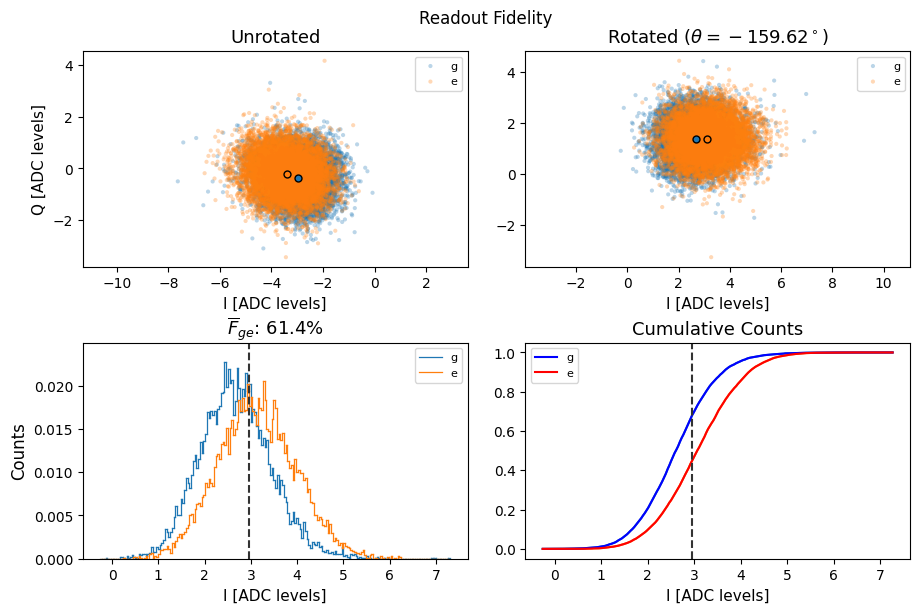

fidelity:[0.6142830483048305] 
thressholds:[2.9589325838835863] 
theta:-159.61501837730123


In [565]:
I_g = iq_list_g[0][0].T[0]
Q_g = iq_list_g[0][0].T[1]
I_e = iq_list_e[0][0].T[0]
Q_e = iq_list_e[0][0].T[1]


data={
    "Ig":I_g,
    "Qg": Q_g,
    "Ie": I_e,
    "Qe": Q_e
}
f = histplot(data, fid_avg=True, fit=False, gauss_overlap=False)

## Readout Optimization

## Gain VS Frequency

In [557]:
freq_steps = 20
freq_step_size = 0.2 # [MHz]
freq_start = (config['f_res']) - ((freq_steps/2)*freq_step_size)
gain_steps = 14
gain_step_size = 0.05 # [DAC units]
gain_start = 0.05
SHOTS = 1000

I_g_array = []
Q_g_array = []
I_e_array = []
Q_e_array = []

for freqs in tqdm(range(freq_steps), desc='Freq loop'):
    I_g_data = []
    Q_g_data = []
    I_e_data = []
    Q_e_data = []
    for gains in tqdm(range(gain_steps), desc='Gain loop', leave=False):
        run_cfg.update({
            ## Sweep Params: ##
            'steps': SHOTS, # Number of shot points (outer loop)
            'f_res': freq_start + freq_step_size*freqs, # [MHz]
            'res_gain': gain_start + gain_step_size*gains, # [DAC units]
            'ro_len':1
            })

        ssp_g = SingleShotProgram_g(soccfg, reps=1, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
        iq_list_g = ssp_g.acquire(soc, soft_avgs=1, progress=False)

        ssp_e = SingleShotProgram_e(soccfg, reps=1, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
        iq_list_e = ssp_e.acquire(soc, soft_avgs=1, progress=False)

        I_g = iq_list_g[0][0].T[0]
        Q_g = iq_list_g[0][0].T[1]
        I_e = iq_list_e[0][0].T[0]
        Q_e = iq_list_e[0][0].T[1]
    
        I_g_data.append([I_g])
        Q_g_data.append([Q_g])
        I_e_data.append([I_e])
        Q_e_data.append([Q_e])

    I_g_array.append([I_g_data])
    Q_g_array.append([Q_g_data])
    I_e_array.append([I_e_data])
    Q_e_array.append([Q_e_data])


Freq loop:   0%|          | 0/20 [00:00<?, ?it/s]

Gain loop:   0%|          | 0/14 [00:00<?, ?it/s]

Gain loop:   0%|          | 0/14 [00:00<?, ?it/s]

Gain loop:   0%|          | 0/14 [00:00<?, ?it/s]

Gain loop:   0%|          | 0/14 [00:00<?, ?it/s]

...

Gain loop:   0%|          | 0/14 [00:00<?, ?it/s]

Gain loop:   0%|          | 0/14 [00:00<?, ?it/s]

Gain loop:   0%|          | 0/14 [00:00<?, ?it/s]

Gain loop:   0%|          | 0/14 [00:00<?, ?it/s]

Gain loop:   0%|          | 0/14 [00:00<?, ?it/s]

C:\Users\QEL\AppData\Local\Temp\ipykernel_9896\3339831831.py:38: UserWarning: The following kwargs were not used by contour: 'interpolation'
  figB = plt.contour(gains_list,freqs_list,fid_Array, 10 ,colors='w',interpolation='none')


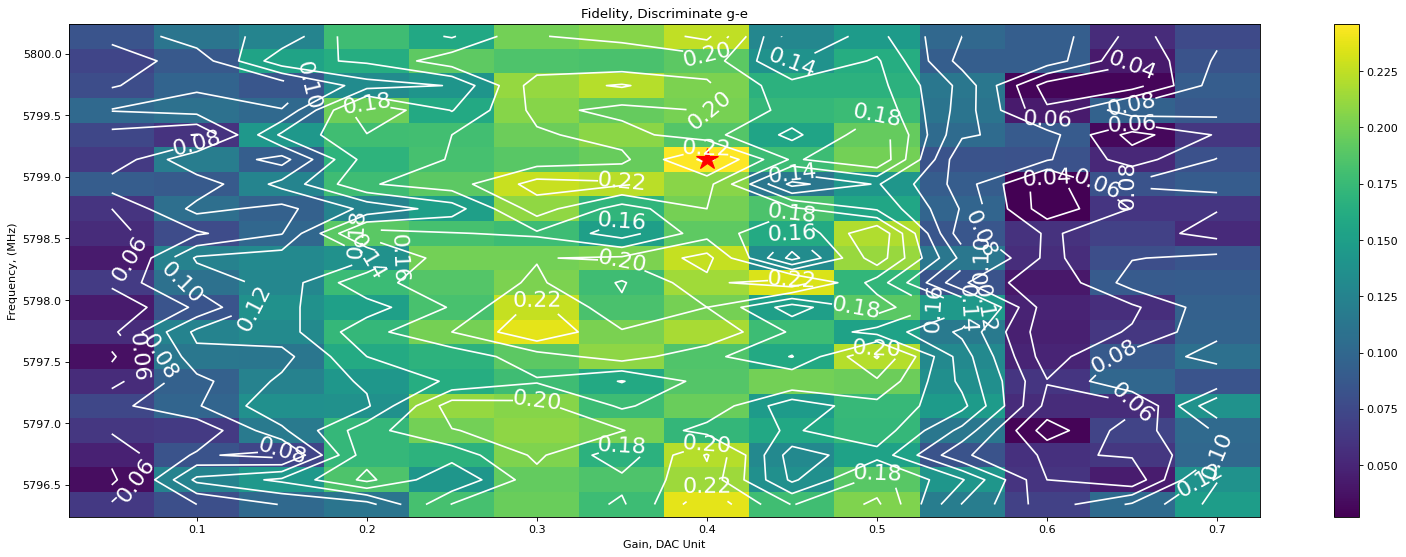

5799.14 0.4


In [559]:
fid_Array =np.zeros([freq_steps,gain_steps])
for index_freq in range(freq_steps):
    for index_amp in range(gain_steps):
        I_g = I_g_array[index_freq][0][index_amp][0]
        Q_g = Q_g_array[index_freq][0][index_amp][0]
        I_e = I_e_array[index_freq][0][index_amp][0]
        Q_e = Q_e_array[index_freq][0][index_amp][0]


        vec_I = np.mean(I_e) - np.mean(I_g)
        vec_Q = np.mean(Q_e) - np.mean(Q_g)
        denom = np.abs(vec_I + 1j * vec_Q) ** 2


        gstate = ((I_g - np.mean(I_g)) * vec_I + (Q_g - np.mean(Q_g)) * vec_Q) / denom
        estate = ((I_e - np.mean(I_g)) * vec_I + (Q_e - np.mean(Q_g)) * vec_Q) / denom

        th_list = np.linspace(min(gstate), max(estate), 1000)
        gstate = gstate.reshape(1, -1)
        estate = estate.reshape(1, -1)
        th_list = th_list.reshape(-1, 1)

        g_cdf = np.sum(gstate < th_list, axis=1) / gstate.shape[1]
        e_cdf = np.sum(estate > th_list, axis=1) / estate.shape[1]
        fidelity = (g_cdf + e_cdf) / 2
        fid_Array[index_freq, index_amp] = 2 * np.max(fidelity) - 1


freqs_list = np.zeros(freq_steps)
gains_list = np.zeros(gain_steps)
for gain in range(gain_steps):
    gains_list[gain] = gain_start + gain_step_size*gain
for freq in range(freq_steps):
    freqs_list[freq] = freq_start + freq_step_size*freq

plt.figure(figsize=(24, 8), dpi=80)
figA = plt.pcolormesh(gains_list,freqs_list,fid_Array)
figB = plt.contour(gains_list,freqs_list,fid_Array, 10 ,colors='w',interpolation='none')
plt.clabel(figB, figB.levels, inline=True, fontsize=20)
plt.xlabel(r"Gain, DAC Unit")
plt.ylabel(r"Frequency, (MHz)")
max_idx = np.unravel_index(np.argmax(fid_Array), fid_Array.shape)
max_freq_idx, max_gain_idx = max_idx
max_freq = freqs_list[max_freq_idx]
max_gain = gains_list[max_gain_idx]
plt.plot(max_gain, max_freq, marker='*', color='red', markersize=20, label='Max Fidelity')
plt.title(r"Fidelity, Discriminate g-e")
plt.colorbar(figA)
plt.show()
print(max_freq, max_gain)
run_cfg['f_res'] = round(max_freq,3)
run_cfg['res_gain'] = round(max_gain,3)
#plt.savefig("FidwithoutJPA.png",dpi=300,bbox_inches='tight')

### Length VS Frequency

In [562]:
freq_steps = 20
freq_step_size = 0.2 # [MHz]
freq_start = (config['f_res']) - ((freq_steps/2)*freq_step_size)
length_steps = 20
length_step_size = 0.2 # [us units]
length_start = 0.5
SHOTS = 1000

I_g_array = []
Q_g_array = []
I_e_array = []
Q_e_array = []

for freqs in tqdm(range(freq_steps), desc='Freq loop'):
    I_g_data = []
    Q_g_data = []
    I_e_data = []
    Q_e_data = []
    for lengths in tqdm(range(length_steps), desc='ro len loop', leave=False):
        run_cfg.update({'steps': SHOTS,
                        'f_res': freq_start + freq_step_size*freqs,
                        'ro_len': length_start + length_step_size*lengths,
                        })


        ssp_g = SingleShotProgram_g(soccfg, reps=1, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
        iq_list_g = ssp_g.acquire(soc, soft_avgs=1, progress=False)

        ssp_e = SingleShotProgram_e(soccfg, reps=1, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
        iq_list_e = ssp_e.acquire(soc, soft_avgs=1, progress=False)

        I_g = iq_list_g[0][0].T[0]
        Q_g = iq_list_g[0][0].T[1]
        I_e = iq_list_e[0][0].T[0]
        Q_e = iq_list_e[0][0].T[1]
    
        I_g_data.append([I_g])
        Q_g_data.append([Q_g])
        I_e_data.append([I_e])
        Q_e_data.append([Q_e])

    I_g_array.append([I_g_data])
    Q_g_array.append([Q_g_data])
    I_e_array.append([I_e_data])
    Q_e_array.append([Q_e_data])


Freq loop:   0%|          | 0/20 [00:00<?, ?it/s]

ro len loop:   0%|          | 0/20 [00:00<?, ?it/s]

ro len loop:   0%|          | 0/20 [00:00<?, ?it/s]

ro len loop:   0%|          | 0/20 [00:00<?, ?it/s]

ro len loop:   0%|          | 0/20 [00:00<?, ?it/s]

...

ro len loop:   0%|          | 0/20 [00:00<?, ?it/s]

ro len loop:   0%|          | 0/20 [00:00<?, ?it/s]

ro len loop:   0%|          | 0/20 [00:00<?, ?it/s]

ro len loop:   0%|          | 0/20 [00:00<?, ?it/s]

ro len loop:   0%|          | 0/20 [00:00<?, ?it/s]

C:\Users\QEL\AppData\Local\Temp\ipykernel_9896\1858233137.py:38: UserWarning: The following kwargs were not used by contour: 'interpolation'
  figB = plt.contour(lengths_list,freqs_list,fid_Array, 10 ,colors='w',interpolation='none')


5798.9400000000005 3.5


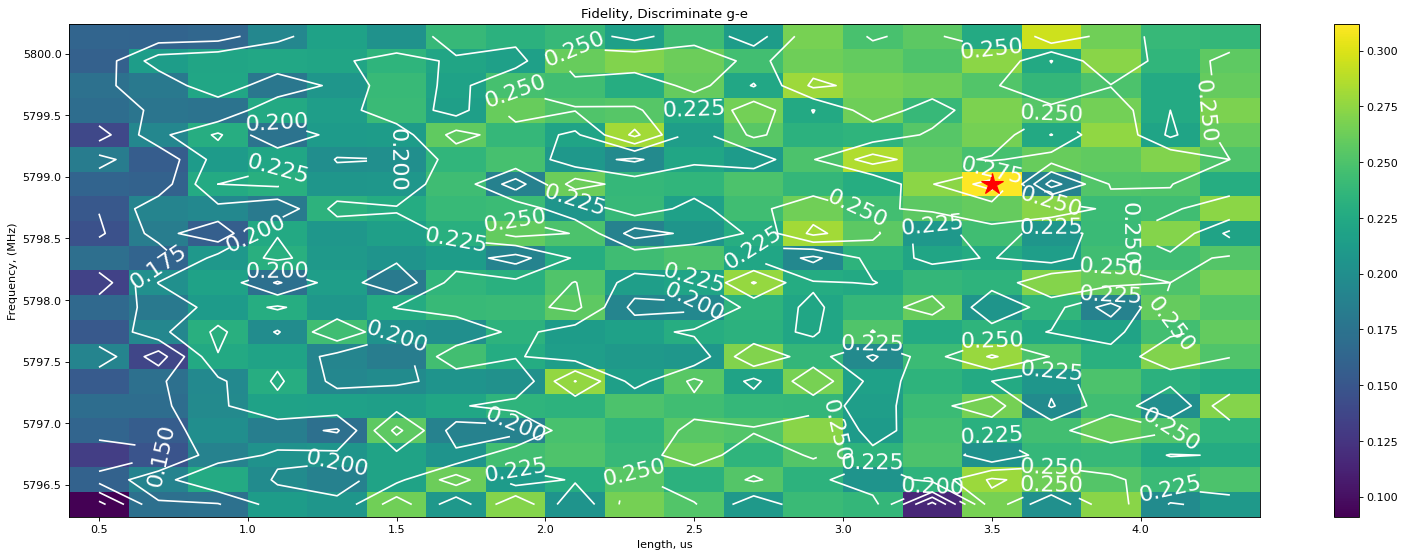

In [563]:
fid_Array = np.zeros((freq_steps, length_steps))

for index_freq in range(freq_steps):
    for index_length in range(length_steps):
        I_g = I_g_array[index_freq][0][index_length][0]
        Q_g = Q_g_array[index_freq][0][index_length][0]
        I_e = I_e_array[index_freq][0][index_length][0]
        Q_e = Q_e_array[index_freq][0][index_length][0]

        vec_I = np.mean(I_e) - np.mean(I_g)
        vec_Q = np.mean(Q_e) - np.mean(Q_g)
        denom = np.abs(vec_I + 1j * vec_Q)**2

        gstate = ((I_g - np.mean(I_g)) * vec_I + (Q_g - np.mean(Q_g)) * vec_Q) / denom
        estate = ((I_e - np.mean(I_g)) * vec_I + (Q_e - np.mean(Q_g)) * vec_Q) / denom


        th_list = np.linspace(np.min(gstate), np.max(estate), 1000).reshape(-1, 1)
        g_proj = np.array(gstate).reshape(1, -1)
        e_proj = np.array(estate).reshape(1, -1)

        g_cdf = np.sum(g_proj < th_list, axis=1) / g_proj.shape[1]
        e_cdf = np.sum(e_proj > th_list, axis=1) / e_proj.shape[1]
        fidelity = (g_cdf + e_cdf) / 2

        fid_Array[index_freq, index_length] = 2 * np.max(fidelity) - 1


freqs_list = np.zeros(freq_steps)
lengths_list = np.zeros(length_steps)
for length in range(length_steps):
    lengths_list[length] = length_start + length_step_size*length
for freq in range(freq_steps):
    freqs_list[freq] = freq_start + freq_step_size*freq

plt.figure(figsize=(24, 8), dpi=80)
figA = plt.pcolormesh(lengths_list,freqs_list,fid_Array)
figB = plt.contour(lengths_list,freqs_list,fid_Array, 10 ,colors='w',interpolation='none')
plt.clabel(figB, figB.levels, inline=True, fontsize=20)
plt.xlabel(r"length, us")
plt.ylabel(r"Frequency, (MHz)")
plt.title(r"Fidelity, Discriminate g-e")
max_idx = np.unravel_index(np.argmax(fid_Array), fid_Array.shape)
max_freq_idx, max_length_idx = max_idx
max_freq = freqs_list[max_freq_idx]
max_length = lengths_list[max_length_idx]
plt.plot(max_length, max_freq, marker='*', color='red', markersize=20, label='Max Fidelity')
plt.colorbar(figA)

print(max_freq, max_length)
run_cfg['f_res'] = round(max_freq, 3)
run_cfg['ro_len'] = round(max_length, 2)

### Gain vs Length

In [ ]:
gain_steps = 14
gain_step_size = 0.05 # [DAC units]
gain_start = 0.05

length_steps = 10
length_step_size = 0.2 # [us units]
length_start = 0.5
SHOTS = 1000

I_g_array = []
Q_g_array = []
I_e_array = []
Q_e_array = []

for freqs in tqdm(range(gain_steps), desc='Gain loop'):
    I_g_data = []
    Q_g_data = []
    I_e_data = []
    Q_e_data = []
    for lengths in tqdm(range(length_steps), desc='ro len loop', leave=False):
        run_cfg.update({'steps': SHOTS,
                        'f_res': 5799,
                        'ro_len': length_start + length_step_size*lengths,
                        'res_gain': gain_start + gain_step_size*gains, # [DAC units]
                        })


        ssp_g = SingleShotProgram_g(soccfg, reps=1, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
        iq_list_g = ssp_g.acquire(soc, soft_avgs=1, progress=False)

        ssp_e = SingleShotProgram_e(soccfg, reps=1, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
        iq_list_e = ssp_e.acquire(soc, soft_avgs=1, progress=False)

        I_g = iq_list_g[0][0].T[0]
        Q_g = iq_list_g[0][0].T[1]
        I_e = iq_list_e[0][0].T[0]
        Q_e = iq_list_e[0][0].T[1]
    
        I_g_data.append([I_g])
        Q_g_data.append([Q_g])
        I_e_data.append([I_e])
        Q_e_data.append([Q_e])

    I_g_array.append([I_g_data])
    Q_g_array.append([Q_g_data])
    I_e_array.append([I_e_data])
    Q_e_array.append([Q_e_data])


In [ ]:
fid_Array = np.zeros((gain_steps, length_steps))

for index_gain in range(gain_steps):
    for index_length in range(length_steps):
        I_g = I_g_array[index_gain][0][index_length][0]
        Q_g = Q_g_array[index_gain][0][index_length][0]
        I_e = I_e_array[index_gain][0][index_length][0]
        Q_e = Q_e_array[index_gain][0][index_length][0]

        vec_I = np.mean(I_e) - np.mean(I_g)
        vec_Q = np.mean(Q_e) - np.mean(Q_g)
        denom = np.abs(vec_I + 1j * vec_Q)**2

        gstate = ((I_g - np.mean(I_g)) * vec_I + (Q_g - np.mean(Q_g)) * vec_Q) / denom
        estate = ((I_e - np.mean(I_g)) * vec_I + (Q_e - np.mean(Q_g)) * vec_Q) / denom


        th_list = np.linspace(np.min(gstate), np.max(estate), 1000).reshape(-1, 1)
        g_proj = np.array(gstate).reshape(1, -1)
        e_proj = np.array(estate).reshape(1, -1)

        g_cdf = np.sum(g_proj < th_list, axis=1) / g_proj.shape[1]
        e_cdf = np.sum(e_proj > th_list, axis=1) / e_proj.shape[1]
        fidelity = (g_cdf + e_cdf) / 2

        fid_Array[index_gain, index_length] = 2 * np.max(fidelity) - 1


gain_list = np.zeros(gain_steps)
lengths_list = np.zeros(length_steps)
for length in range(length_steps):
    lengths_list[length] = length_start + length_step_size*length
for gain in range(gain_steps):
    gain_list[gain] = gain_start + gain_step_size*gain

plt.figure(figsize=(24, 8), dpi=80)
figA = plt.pcolormesh(lengths_list,gain_list,fid_Array)
figB = plt.contour(lengths_list,gain_list,fid_Array, 10 ,colors='w',interpolation='none')
plt.clabel(figB, figB.levels, inline=True, fontsize=20)
plt.xlabel(r"length, us")
plt.ylabel(r"Gain (Dac unit)")
plt.title(r"Fidelity, Discriminate g-e")
max_idx = np.unravel_index(np.argmax(fid_Array), fid_Array.shape)
max_gain_idx, max_length_idx = max_idx
max_gain = gain_list[max_gain_idx]
max_length = lengths_list[max_length_idx]
plt.plot(max_length, max_gain, marker='*', color='red', markersize=20, label='Max Fidelity')
plt.colorbar(figA)
plt.show()
print(max_gain, max_length)

# Track

In [ ]:
import time
from datetime import datetime
import os
import pandas as pd
import numpy as np

pyavg = 50
filename = "monitor_log.csv"
i=0


import csv
if not os.path.exists(filename):
    with open(filename, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["timestamp", "T2r", "T2e", "T1"])  # 正確寫入標題
try:
    while True:
        now = datetime.now()
        print(f"Measurement at {now.strftime('%Y-%m-%d %H:%M:%S')}")
        ## T2R ##
        START_TIME = 0.01 # [us]
        STOP_TIME = 2 # [us]
        STEPS = 50
        expt_cfg = {
            ## Sweep Params: ##
            'steps': STEPS, # Number of sweep points
            'wait_time': QickSweep1D('waitloop', START_TIME, STOP_TIME), # [us]
            'ramsey_freq':3
            }
        run_cfg = {**config, **expt_cfg}
        ramsey=RamseyProgram(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
        iq_list = ramsey.acquire(soc, soft_avgs=pyavg, progress=False)
        delay_times = ramsey.get_time_param('wait', "t", as_array=True)
        ramsey = iq_list[0][0].dot([1,1j])
        t2r = T2fring_analyze(delay_times, ramsey)

        ## T2E ##
        START_TIME = 0.01 # [us]
        STOP_TIME = 2 # [us]
        STEPS = 50
        expt_cfg = {
            ## Sweep Params: ##
            'steps': STEPS, # Number of sweep points
            'ramsey_freq':3,
            'wait_time': QickSweep1D('waitloop', START_TIME, STOP_TIME), # [us]
            }
        run_cfg = {**config, **expt_cfg}
        spinecho=SpinEchoProgram(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
        iq_list = spinecho.acquire(soc, soft_avgs=pyavg, progress=False)
        delay_times1 = spinecho.get_time_param('wait1', "t", as_array=True)
        delay_times2 = spinecho.get_time_param('wait2', "t", as_array=True)
        spinecho = iq_list[0][0].dot([1,1j])
        t2e = T2fring_analyze(delay_times1+delay_times2, np.abs(spinecho))

        ## T1 ##
        START_TIME = 0.05 # [us]
        STOP_TIME = 60.0 # [us]
        STEPS = 50
        expt_cfg = {
            ## Sweep Params: ##
            'steps': STEPS, # Number of sweep points
            'wait_time': QickSweep1D('waitloop', START_TIME, STOP_TIME), # [us]
            }
        run_cfg = {**config, **expt_cfg}
        T1=T1Program(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
        iq_list = T1.acquire(soc, soft_avgs=pyavg, progress=False)
        delay_times = T1.get_time_param('wait', "t", as_array=True)
        t1 = T1_analyze(delay_times, np.abs(iq_list[0][0].dot([1,1j])))

        t2r_list = [t2r[3], t2r[1]-3]
        t2e_list = [t2e[3], t2e[1]-3]
        t1_value = t1[3]
        with open(filename, "a", newline="") as f:
            writer = csv.writer(f)
            writer.writerow([now.isoformat(), t2r_list, t2e_list, t1_value])
except KeyboardInterrupt:

    print("\n手動中斷量測，資料已保留。")


# Dispersive shift

In [ ]:
class Dispersive_e(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        qubit_ch = cfg['qubit_ch']
        self.declare_gen(ch=res_ch, nqz=2)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        loopbefore  = AsmV2()
        loopbefore.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        self.add_loop("freqloop", cfg["steps"], exec_before=loopbefore)
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)

        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][qubit_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=2, mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=2)

        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch, 
                       style="const", 
                       length=100, 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )
        self.add_gauss(ch=qubit_ch, name="ramp", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
        if cfg['qb_pulse_style']=='arb':
            self.add_pulse(ch=qubit_ch, name="qubit_pulse", 
                        style="arb", 
                        envelope="ramp", 
                        freq=cfg['f_ge'],
                        phase=cfg['qubit_phase'],
                        gain=cfg['pi_gain'], 
                        )
        elif cfg['qb_pulse_style']=='flat_top':
            self.add_pulse(ch=qubit_ch, name="qubit_pulse", 
                           style="flat_top", 
                           envelope="ramp", 
                           length = cfg['flat_top_len'],
                           freq=cfg['f_ge'], 
                           phase= cfg['qubit_phase'],
                           gain=cfg['pi_gain'],
                          )
    def _body(self, cfg):
        # self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        self.pulse(ch=self.cfg["qubit_ch"], name="qubit_pulse", t=0)  #play pulse
        self.delay_auto(0.015, tag='wait') # wait_time after last pulse

        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

class Dispersive_g(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        qubit_ch = cfg['qubit_ch']
        self.declare_gen(ch=res_ch, nqz=2)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        loopbefore  = AsmV2()
        loopbefore.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        self.add_loop("freqloop", cfg["steps"], exec_before=loopbefore)
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)

        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][qubit_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=2, mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=2)

        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch, 
                       style="const", 
                       length=100, 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )

    def _body(self, cfg):
        # self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)


        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

In [ ]:
center = r[qubit_idx]
START_FREQ = center - 10 # [MHz]
STOP_FREQ =  center + 10 # [MHz]
STEPS = 101

exp_cfg = {
    'steps': STEPS, # Number of sweep points
    'f_res': QickSweep1D('freqloop', START_FREQ, STOP_FREQ), # [MHz]
    'res_gain': 0.1
}
run_cfg = {**config, **exp_cfg}

In [ ]:
pyavg = 10
run_cfg['ro_len'] = 2

prog = Dispersive_e(soccfg, reps=100, final_delay=40, cfg=run_cfg)
iq_list = prog.acquire(soc, soft_avgs=pyavg, progress=True)
freqs = prog.get_pulse_param("res_pulse", "freq", as_array=True)
dispersive_e = (iq_list[0][0].dot([1,1j]))

prog = Dispersive_g(soccfg, reps=100, final_delay=40, cfg=run_cfg)
iq_list = prog.acquire(soc, soft_avgs=pyavg, progress=True)
dispersive_g = (iq_list[0][0].dot([1,1j]))
dispersive_analyze(freqs, dispersive_e, dispersive_g)

# pulse train

In [194]:
class PulseTrain(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        qubit_ch = cfg['qubit_ch']
        
        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][qubit_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'], mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'])
        # pynq configured
        # self.declare_readout(ch=ro_ch, length=cfg['ro_len'], freq=cfg['f_res'], gen_ch=res_ch)
        
        # tproc configured
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)

        self.add_loop("gainloop", cfg["steps"])

        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch, 
                       style="const",
                       length=cfg['res_len'], 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )
        
        self.add_gauss(ch=qubit_ch, name="ramp", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
        if cfg['qb_pulse_style']=='arb':
            self.add_pulse(ch=qubit_ch, name="qubit_pulse", 
                        style="arb", 
                        envelope="ramp", 
                        freq=cfg['f_ge'], 
                        phase= cfg['qubit_phase'],
                        gain=cfg['qubit_gain'],
                        )
        elif cfg['qb_pulse_style']=='flat_top':
            self.add_pulse(ch=qubit_ch, name="qubit_pulse", 
                           style="flat_top", 
                           envelope="ramp", 
                           freq=cfg['f_ge'], 
                           phase= cfg['qubit_phase'],
                           gain=cfg['qubit_gain'],
                           length = cfg['flat_top_len']
                          )
        
    def _body(self, cfg):
        for i in range(cfg['iter']):
            if i==0:
                pass
            else:
                self.pulse(ch=cfg["qubit_ch"], name="qubit_pulse", t=0)  
                self.delay_auto(0.0)
                self.pulse(ch=cfg["qubit_ch"], name="qubit_pulse", t=0)
                self.delay_auto(0.0)

        self.delay_auto(t=0.05, tag='waiting')
        self.pulse(ch=cfg['res_ch'], name="res_pulse", t = 0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

In [217]:
START_GAIN = 0.0 # [DAC units]
STOP_GAIN = 1 # [DAC units]
STEPS = 200


config.update({'relax_delay':100, 'qb_pulse_style':'arb', 'sigma':0.01, 'flat_top_len':0.1})
expt_cfg = {
    ## Sweep Params: ##
    'steps': STEPS, # Number of sweep points
    'qmixer_freq':config['f_ge'],
    "qubit_gain": QickSweep1D('gainloop', START_GAIN, STOP_GAIN), # [DAC units]
     }
run_cfg = {**config, **expt_cfg}

In [201]:
pyavg = 100
iterlsit = np.arange(0, 30, 2)

pulse_train=[]
for i in tqdm(iterlsit, desc='amp pulse train'):
    run_cfg['iter'] = i
    amp_rabi=PulseTrain(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
    iq_list = amp_rabi.acquire(soc, soft_avgs=pyavg, progress=False, threshold=run_cfg['thresholds'])
    gains = amp_rabi.get_pulse_param('qubit_pulse', "gain", as_array=True)
    power_rabi = iq_list[0][0].dot([1,1j])
    pulse_train.append(power_rabi)

amp pulse train:   0%|          | 0/10 [00:00<?, ?it/s]

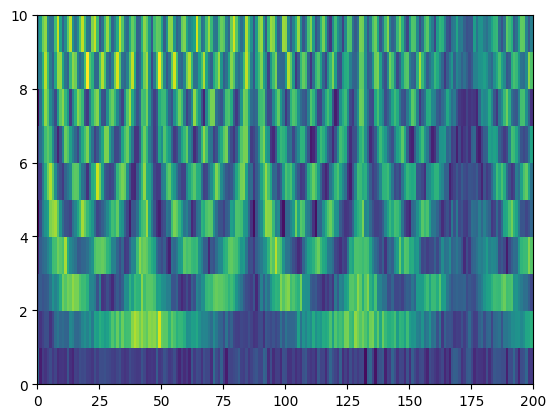

In [202]:
plt.pcolor(np.abs(pulse_train))

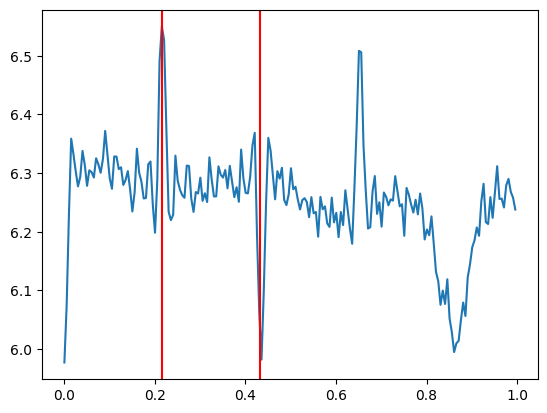

In [219]:
z=0
z2=0
for i in range(len(pulse_train)):
    z+=pulse_train[i]
run_cfg['iter']=0
amp_rabi=PulseTrain(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)

gains = amp_rabi.get_pulse_param('qubit_pulse', "gain", as_array=True)

plt.plot(gains,np.abs(z))
plt.axvline(run_cfg['pi2_gain'],color='r')
plt.axvline(run_cfg['pi_gain'],color='r')

# ALL XY

In [623]:
class AllXY(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        qubit_ch = cfg['qubit_ch']
        
        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][qubit_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'], mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'])
        # pynq configured
        # self.declare_readout(ch=ro_ch, length=cfg['ro_len'], freq=cfg['f_res'], gen_ch=res_ch)
        
        # tproc configured
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)
        
        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch, 
                       style="const", 
                       length=cfg['res_len'], 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )
        
        self.add_gauss(ch=qubit_ch, name="ramp", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
        if cfg['qb_pulse_style']=='arb':
            self.add_pulse(ch=qubit_ch, name="x180", 
                        style="arb", 
                        envelope="ramp", 
                        freq=cfg['f_ge'],
                        phase=0,
                        gain=cfg['pi_gain'], 
                        )
            self.add_pulse(ch=qubit_ch, name="x90", 
                    style="arb", 
                    envelope="ramp", 
                    freq=cfg['f_ge'], 
                    phase=0,
                    gain=cfg['pi2_gain'], 
                    )
            self.add_pulse(ch=qubit_ch, name="y180", 
                        style="arb", 
                        envelope="ramp", 
                        freq=cfg['f_ge'],
                        phase=90,
                        gain=cfg['pi_gain'], 
                        )
            self.add_pulse(ch=qubit_ch, name="y90", 
                    style="arb", 
                    envelope="ramp", 
                    freq=cfg['f_ge'], 
                    phase=90,
                    gain=cfg['pi2_gain'], 
                    )
        elif cfg['qb_pulse_style']=='flat_top':
            self.add_pulse(ch=qubit_ch, name="x180", 
                        style="flat_top", 
                        envelope="ramp", 
                        freq=cfg['f_ge'],
                        phase=0,
                        gain=cfg['pi_gain'], 
                        length = cfg['flat_top_len'],
                        )
            self.add_pulse(ch=qubit_ch, name="x90", 
                    style="flat_top", 
                    envelope="ramp", 
                    freq=cfg['f_ge'], 
                    phase=0,
                    gain=cfg['pi2_gain'], 
                    length = cfg['flat_top_len'],
                    )
            self.add_pulse(ch=qubit_ch, name="y180", 
                        style="flat_top", 
                        envelope="ramp", 
                        freq=cfg['f_ge'],
                        phase=90,
                        gain=cfg['pi_gain'], 
                        length = cfg['flat_top_len'],
                        )
            self.add_pulse(ch=qubit_ch, name="y90", 
                    style="flat_top", 
                    envelope="ramp", 
                    freq=cfg['f_ge'], 
                    phase=90,
                    gain=cfg['pi2_gain'], 
                    length = cfg['flat_top_len'],
                    )
    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        if cfg['allxy_gates'][0]=='I':
            pass 
        else:
            self.pulse(ch=self.cfg["qubit_ch"], name=f"{self.cfg['allxy_gates'][0]}", t=0) 
        self.delay_auto(0.01) 
        if cfg['allxy_gates'][1]=='I':
            pass 
        else:
            self.pulse(ch=self.cfg["qubit_ch"], name=f"{self.cfg['allxy_gates'][1]}", t=0) 
        
        self.delay_auto(0.05) # wait_time after last pulse
        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0) # play probe pulse
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

In [624]:
sequence = [
    ("I", "I"),
    ("x180", "x180"),
    ("y180", "y180"),
    ("x180", "y180"),
    ("y180", "x180"),
    ("x90", "I"),
    ("y90", "I"),
    ("x90", "y90"),
    ("y90", "x90"),
    ("x90", "y180"),
    ("y90", "x180"),
    ("x180", "y90"),
    ("y180", "x90"),
    ("x90", "x180"),
    ("x180", "x90"),
    ("y90", "y180"),
    ("y180", "y90"),
    ("x180", "I"),
    ("y180", "I"),
    ("x90", "x90"),
    ("y90", "y90"),
]


  0%|          | 0/21 [00:00<?, ?it/s]

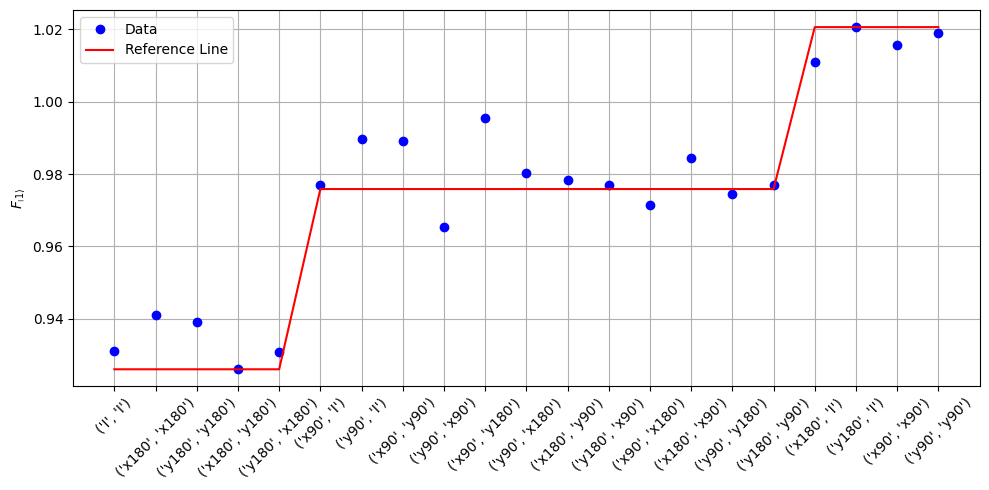

In [636]:
pyavg = 150

allxy_lst=[]
for gate in tqdm(sequence):
    run_cfg['allxy_gates'] = gate
    allxy=AllXY(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
    iq_list = allxy.acquire(soc, soft_avgs=pyavg, progress=False, threshold=run_cfg['thresholds'])
    allxy_lst.append(iq_list[0][0].dot([1,1j]))

amp = np.abs(allxy_lst)
plt.figure(figsize=(10, 5))
plt.plot(amp, 'bo', label='Data')
plt.plot([np.min(amp)]*5 + [np.mean(amp)]*12 + [np.max(amp)]*4, 'r-', label='Reference Line')
plt.xticks(np.arange(len(sequence)), sequence, rotation=45)
plt.ylabel(r'$F_{\left|1\right\rangle}$')
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()

# Track

In [ ]:
import time
from datetime import datetime
import os
import pandas as pd
import numpy as np

pyavg = 50
filename = "monitor_log.csv"
i=0


import csv
if not os.path.exists(filename):
    with open(filename, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["timestamp", "T2r", "T2e", "T1"])  # 正確寫入標題
try:
    while True:
        now = datetime.now()
        print(f"Measurement at {now.strftime('%Y-%m-%d %H:%M:%S')}")
        ## T2R ##
        START_TIME = 0.01 # [us]
        STOP_TIME = 2 # [us]
        STEPS = 50
        expt_cfg = {
            ## Sweep Params: ##
            'steps': STEPS, # Number of sweep points
            'wait_time': QickSweep1D('waitloop', START_TIME, STOP_TIME), # [us]
            'ramsey_freq':3
            }
        run_cfg = {**config, **expt_cfg}
        ramsey=RamseyProgram(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
        iq_list = ramsey.acquire(soc, soft_avgs=pyavg, progress=False)
        delay_times = ramsey.get_time_param('wait', "t", as_array=True)
        ramsey = iq_list[0][0].dot([1,1j])
        t2r = T2fring_analyze(delay_times, ramsey)

        ## T2E ##
        START_TIME = 0.01 # [us]
        STOP_TIME = 2 # [us]
        STEPS = 50
        expt_cfg = {
            ## Sweep Params: ##
            'steps': STEPS, # Number of sweep points
            'ramsey_freq':3,
            'wait_time': QickSweep1D('waitloop', START_TIME, STOP_TIME), # [us]
            }
        run_cfg = {**config, **expt_cfg}
        spinecho=SpinEchoProgram(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
        iq_list = spinecho.acquire(soc, soft_avgs=pyavg, progress=False)
        delay_times1 = spinecho.get_time_param('wait1', "t", as_array=True)
        delay_times2 = spinecho.get_time_param('wait2', "t", as_array=True)
        spinecho = iq_list[0][0].dot([1,1j])
        t2e = T2fring_analyze(delay_times1+delay_times2, np.abs(spinecho))

        ## T1 ##
        START_TIME = 0.05 # [us]
        STOP_TIME = 60.0 # [us]
        STEPS = 50
        expt_cfg = {
            ## Sweep Params: ##
            'steps': STEPS, # Number of sweep points
            'wait_time': QickSweep1D('waitloop', START_TIME, STOP_TIME), # [us]
            }
        run_cfg = {**config, **expt_cfg}
        T1=T1Program(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
        iq_list = T1.acquire(soc, soft_avgs=pyavg, progress=False)
        delay_times = T1.get_time_param('wait', "t", as_array=True)
        t1 = T1_analyze(delay_times, np.abs(iq_list[0][0].dot([1,1j])))

        t2r_list = [t2r[3], t2r[1]-3]
        t2e_list = [t2e[3], t2e[1]-3]
        t1_value = t1[3]
        with open(filename, "a", newline="") as f:
            writer = csv.writer(f)
            writer.writerow([now.isoformat(), t2r_list, t2e_list, t1_value])
except KeyboardInterrupt:

    print("\n手動中斷量測，資料已保留。")


# Dispersive shift

In [ ]:
class Dispersive_e(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        qubit_ch = cfg['qubit_ch']
        self.declare_gen(ch=res_ch, nqz=2)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        loopbefore  = AsmV2()
        loopbefore.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        self.add_loop("freqloop", cfg["steps"], exec_before=loopbefore)
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)

        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][qubit_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=2, mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=2)

        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch, 
                       style="const", 
                       length=100, 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )
        self.add_gauss(ch=qubit_ch, name="ramp", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
        if cfg['qb_pulse_style']=='arb':
            self.add_pulse(ch=qubit_ch, name="qubit_pulse", 
                        style="arb", 
                        envelope="ramp", 
                        freq=cfg['f_ge'],
                        phase=cfg['qubit_phase'],
                        gain=cfg['pi_gain'], 
                        )
        elif cfg['qb_pulse_style']=='flat_top':
            self.add_pulse(ch=qubit_ch, name="qubit_pulse", 
                           style="flat_top", 
                           envelope="ramp", 
                           length = cfg['flat_top_len'],
                           freq=cfg['f_ge'], 
                           phase= cfg['qubit_phase'],
                           gain=cfg['pi_gain'],
                          )
    def _body(self, cfg):
        # self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        self.pulse(ch=self.cfg["qubit_ch"], name="qubit_pulse", t=0)  #play pulse
        self.delay_auto(0.015, tag='wait') # wait_time after last pulse

        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

class Dispersive_g(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        qubit_ch = cfg['qubit_ch']
        self.declare_gen(ch=res_ch, nqz=2)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        loopbefore  = AsmV2()
        loopbefore.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        self.add_loop("freqloop", cfg["steps"], exec_before=loopbefore)
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)

        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][qubit_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=2, mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=2)

        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch, 
                       style="const", 
                       length=100, 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )

    def _body(self, cfg):
        # self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)


        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

In [ ]:
center = r[qubit_idx]
START_FREQ = center - 10 # [MHz]
STOP_FREQ =  center + 10 # [MHz]
STEPS = 101

exp_cfg = {
    'steps': STEPS, # Number of sweep points
    'f_res': QickSweep1D('freqloop', START_FREQ, STOP_FREQ), # [MHz]
    'res_gain': 0.1
}
run_cfg = {**config, **exp_cfg}

In [ ]:
pyavg = 10
run_cfg['ro_len'] = 2

prog = Dispersive_e(soccfg, reps=100, final_delay=40, cfg=run_cfg)
iq_list = prog.acquire(soc, soft_avgs=pyavg, progress=True)
freqs = prog.get_pulse_param("res_pulse", "freq", as_array=True)
dispersive_e = (iq_list[0][0].dot([1,1j]))

prog = Dispersive_g(soccfg, reps=100, final_delay=40, cfg=run_cfg)
iq_list = prog.acquire(soc, soft_avgs=pyavg, progress=True)
dispersive_g = (iq_list[0][0].dot([1,1j]))
dispersive_analyze(freqs, dispersive_e, dispersive_g)

# pulse train

In [ ]:
class PulseTrain(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        qubit_ch = cfg['qubit_ch']
        
        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][qubit_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'], mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'])
        # pynq configured
        # self.declare_readout(ch=ro_ch, length=cfg['ro_len'], freq=cfg['f_res'], gen_ch=res_ch)
        
        # tproc configured
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)

        self.add_loop("gainloop", cfg["steps"])

        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch, 
                       style="const",
                       length=cfg['res_len'], 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )
        
        self.add_gauss(ch=qubit_ch, name="ramp", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
        if cfg['qb_pulse_style']=='arb':
            self.add_pulse(ch=qubit_ch, name="qubit_pulse", 
                        style="arb", 
                        envelope="ramp", 
                        freq=cfg['f_ge'], 
                        phase= cfg['qubit_phase'],
                        gain=cfg['qubit_gain'],
                        )
        elif cfg['qb_pulse_style']=='flat_top':
            self.add_pulse(ch=qubit_ch, name="qubit_pulse", 
                           style="flat_top", 
                           envelope="ramp", 
                           freq=cfg['f_ge'], 
                           phase= cfg['qubit_phase'],
                           gain=cfg['qubit_gain'],
                           length = cfg['flat_top_len']
                          )
        
    def _body(self, cfg):
        for i in range(cfg['iter']):
            if i==0:
                pass
            else:
                self.pulse(ch=cfg["qubit_ch"], name="qubit_pulse", t=0)  
                self.delay_auto(0.0)
                self.pulse(ch=cfg["qubit_ch"], name="qubit_pulse", t=0)
                self.delay_auto(0.0)

        self.delay_auto(t=0.05, tag='waiting')
        self.pulse(ch=cfg['res_ch'], name="res_pulse", t = 0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

In [ ]:
START_GAIN = 0.0 # [DAC units]
STOP_GAIN = 1 # [DAC units]
STEPS = 200


config.update({'relax_delay':100, 'qb_pulse_style':'arb', 'sigma':0.01, 'flat_top_len':0.1})
expt_cfg = {
    ## Sweep Params: ##
    'steps': STEPS, # Number of sweep points
    'qmixer_freq':config['f_ge'],
    "qubit_gain": QickSweep1D('gainloop', START_GAIN, STOP_GAIN), # [DAC units]
     }
run_cfg = {**config, **expt_cfg}

In [ ]:
pyavg = 100
iterlsit = np.arange(0, 30, 2)

pulse_train=[]
for i in tqdm(iterlsit, desc='amp pulse train'):
    run_cfg['iter'] = i
    amp_rabi=PulseTrain(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
    iq_list = amp_rabi.acquire(soc, soft_avgs=pyavg, progress=False, threshold=run_cfg['thresholds'])
    gains = amp_rabi.get_pulse_param('qubit_pulse', "gain", as_array=True)
    power_rabi = iq_list[0][0].dot([1,1j])
    pulse_train.append(power_rabi)

amp pulse train:   0%|          | 0/10 [00:00<?, ?it/s]

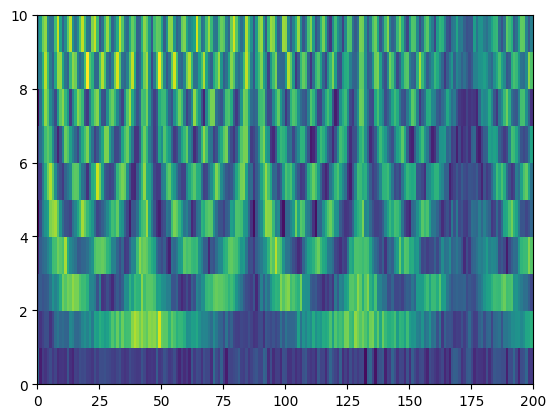

In [ ]:
plt.pcolor(np.abs(pulse_train))

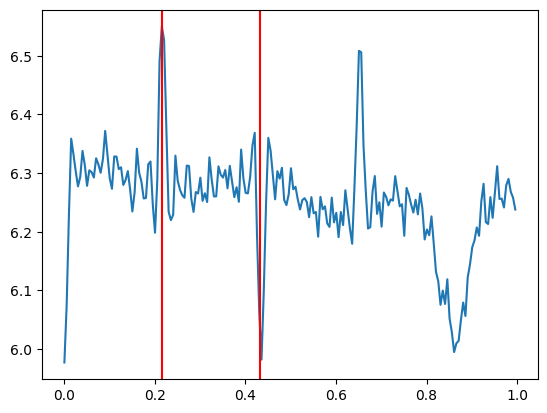

In [ ]:
z=0
z2=0
for i in range(len(pulse_train)):
    z+=pulse_train[i]
run_cfg['iter']=0
amp_rabi=PulseTrain(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)

gains = amp_rabi.get_pulse_param('qubit_pulse', "gain", as_array=True)

plt.plot(gains,np.abs(z))
plt.axvline(run_cfg['pi2_gain'],color='r')
plt.axvline(run_cfg['pi_gain'],color='r')

# ALL XY

In [ ]:
class AllXY(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        qubit_ch = cfg['qubit_ch']
        
        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][qubit_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'], mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'])
        # pynq configured
        # self.declare_readout(ch=ro_ch, length=cfg['ro_len'], freq=cfg['f_res'], gen_ch=res_ch)
        
        # tproc configured
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)
        
        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch, 
                       style="const", 
                       length=cfg['res_len'], 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )
        
        self.add_gauss(ch=qubit_ch, name="ramp", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
        if cfg['qb_pulse_style']=='arb':
            self.add_pulse(ch=qubit_ch, name="x180", 
                        style="arb", 
                        envelope="ramp", 
                        freq=cfg['f_ge'],
                        phase=0,
                        gain=cfg['pi_gain'], 
                        )
            self.add_pulse(ch=qubit_ch, name="x90", 
                    style="arb", 
                    envelope="ramp", 
                    freq=cfg['f_ge'], 
                    phase=0,
                    gain=cfg['pi2_gain'], 
                    )
            self.add_pulse(ch=qubit_ch, name="y180", 
                        style="arb", 
                        envelope="ramp", 
                        freq=cfg['f_ge'],
                        phase=90,
                        gain=cfg['pi_gain'], 
                        )
            self.add_pulse(ch=qubit_ch, name="y90", 
                    style="arb", 
                    envelope="ramp", 
                    freq=cfg['f_ge'], 
                    phase=90,
                    gain=cfg['pi2_gain'], 
                    )
        elif cfg['qb_pulse_style']=='flat_top':
            self.add_pulse(ch=qubit_ch, name="x180", 
                        style="flat_top", 
                        envelope="ramp", 
                        freq=cfg['f_ge'],
                        phase=0,
                        gain=cfg['pi_gain'], 
                        length = cfg['flat_top_len'],
                        )
            self.add_pulse(ch=qubit_ch, name="x90", 
                    style="flat_top", 
                    envelope="ramp", 
                    freq=cfg['f_ge'], 
                    phase=0,
                    gain=cfg['pi2_gain'], 
                    length = cfg['flat_top_len'],
                    )
            self.add_pulse(ch=qubit_ch, name="y180", 
                        style="flat_top", 
                        envelope="ramp", 
                        freq=cfg['f_ge'],
                        phase=90,
                        gain=cfg['pi_gain'], 
                        length = cfg['flat_top_len'],
                        )
            self.add_pulse(ch=qubit_ch, name="y90", 
                    style="flat_top", 
                    envelope="ramp", 
                    freq=cfg['f_ge'], 
                    phase=90,
                    gain=cfg['pi2_gain'], 
                    length = cfg['flat_top_len'],
                    )
    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        if cfg['allxy_gates'][0]=='I':
            pass 
        else:
            self.pulse(ch=self.cfg["qubit_ch"], name=f"{self.cfg['allxy_gates'][0]}", t=0) 
        self.delay_auto(0.01) 
        if cfg['allxy_gates'][1]=='I':
            pass 
        else:
            self.pulse(ch=self.cfg["qubit_ch"], name=f"{self.cfg['allxy_gates'][1]}", t=0) 
        
        self.delay_auto(0.05) # wait_time after last pulse
        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0) # play probe pulse
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

In [868]:
sequence = [
    ("I", "I"),
    ("x180", "x180"),
    ("y180", "y180"),
    ("x180", "y180"),
    ("y180", "x180"),
    ("x90", "I"),
    ("y90", "I"),
    ("x90", "y90"),
    ("y90", "x90"),
    ("x90", "y180"),
    ("y90", "x180"),
    ("x180", "y90"),
    ("y180", "x90"),
    ("x90", "x180"),
    ("x180", "x90"),
    ("y90", "y180"),
    ("y180", "y90"),
    ("x180", "I"),
    ("y180", "I"),
    ("x90", "x90"),
    ("y90", "y90"),
]


  0%|          | 0/21 [00:00<?, ?it/s]

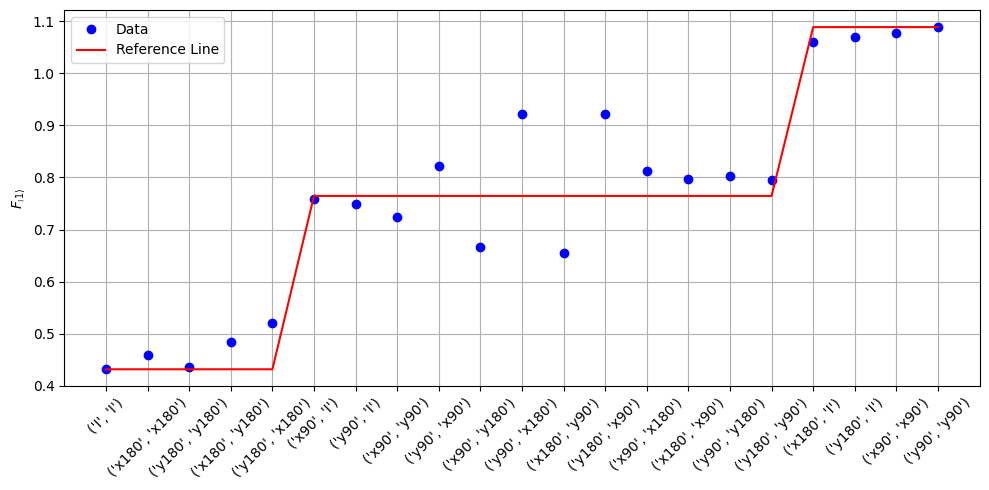

In [869]:
pyavg = 50

allxy_lst=[]
for gate in tqdm(sequence):
    run_cfg['allxy_gates'] = gate
    allxy=AllXY(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
    iq_list = allxy.acquire(soc, soft_avgs=pyavg, progress=False, threshold=run_cfg['thresholds'])
    allxy_lst.append(iq_list[0][0].dot([1,1j]))

amp = np.abs(allxy_lst)
plt.figure(figsize=(10, 5))
plt.plot(amp, 'bo', label='Data')
plt.plot([np.min(amp)]*5 + [np.mean(amp)]*12 + [np.max(amp)]*4, 'r-', label='Reference Line')
plt.xticks(np.arange(len(sequence)), sequence, rotation=45)
plt.ylabel(r'$F_{\left|1\right\rangle}$')
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()

# RB

In [ ]:
class RB(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        qubit_ch = cfg['qubit_ch']
        
        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][qubit_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'], mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'])
        # pynq configured
        # self.declare_readout(ch=ro_ch, length=cfg['ro_len'], freq=cfg['f_res'], gen_ch=res_ch)
        
        # tproc configured
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)
        
        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch, 
                       style="const", 
                       length=cfg['res_len'], 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )
        
        self.add_gauss(ch=qubit_ch, name="ramp", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
        if cfg['qb_pulse_style']=='arb':
            ## X pulse ##
            self.add_pulse(ch=qubit_ch, name="X", 
                        style="arb", 
                        envelope="ramp", 
                        freq=cfg['f_ge'],
                        phase=0,
                        gain=cfg['pi_gain'], 
                        )
            self.add_pulse(ch=qubit_ch, name="-X", 
                        style="arb", 
                        envelope="ramp", 
                        freq=cfg['f_ge'],
                        phase=0,
                        gain=-cfg['pi_gain'], 
                        )
            self.add_pulse(ch=qubit_ch, name="X/2", 
                    style="arb", 
                    envelope="ramp", 
                    freq=cfg['f_ge'], 
                    phase=0,
                    gain=cfg['pi2_gain'], 
                    )
            self.add_pulse(ch=qubit_ch, name="-X/2", 
                    style="arb", 
                    envelope="ramp", 
                    freq=cfg['f_ge'], 
                    phase=0,
                    gain=-cfg['pi2_gain'], 
                    )
            ## Y pulse ##
            self.add_pulse(ch=qubit_ch, name="Y", 
                        style="arb", 
                        envelope="ramp", 
                        freq=cfg['f_ge'],
                        phase=90,
                        gain=cfg['pi_gain'], 
                        )
            self.add_pulse(ch=qubit_ch, name="-Y", 
                        style="arb", 
                        envelope="ramp", 
                        freq=cfg['f_ge'],
                        phase=90,
                        gain=-cfg['pi_gain'], 
                        )
            self.add_pulse(ch=qubit_ch, name="Y/2", 
                    style="arb", 
                    envelope="ramp", 
                    freq=cfg['f_ge'], 
                    phase=90,
                    gain=cfg['pi2_gain'], 
                    )
            self.add_pulse(ch=qubit_ch, name="-Y/2", 
                    style="arb", 
                    envelope="ramp", 
                    freq=cfg['f_ge'], 
                    phase=90,
                    gain=-cfg['pi2_gain'], 
                    )
            
        # elif cfg['qb_pulse_style']=='flat_top':
        #      ## X pulse ##
        #     self.add_pulse(ch=qubit_ch, name="x180", 
        #                 style="flat_top", 
        #                 envelope="ramp", 
        #                 freq=cfg['f_ge'],
        #                 phase=0,
        #                 gain=cfg['pi_gain'], 
        #                 length = cfg['flat_top_len'],
        #                 )
        #     self.add_pulse(ch=qubit_ch, name="-x180", 
        #                 style="flat_top", 
        #                 envelope="ramp", 
        #                 freq=cfg['f_ge'],
        #                 phase=0,
        #                 gain=-cfg['pi_gain'], 
        #                 length = cfg['flat_top_len'],
        #                 )
        #     self.add_pulse(ch=qubit_ch, name="x90", 
        #             style="flat_top", 
        #             envelope="ramp", 
        #             freq=cfg['f_ge'], 
        #             phase=0,
        #             gain=cfg['pi2_gain'], 
        #             length = cfg['flat_top_len'],
        #             )
        #     self.add_pulse(ch=qubit_ch, name="-x90", 
        #             style="flat_top", 
        #             envelope="ramp", 
        #             freq=cfg['f_ge'], 
        #             phase=0,
        #             gain=-cfg['pi2_gain'], 
        #             length = cfg['flat_top_len'],
        #             )
        #     ## Y pulse ##
        #     self.add_pulse(ch=qubit_ch, name="y180", 
        #                 style="flat_top", 
        #                 envelope="ramp", 
        #                 freq=cfg['f_ge'],
        #                 phase=-90,
        #                 gain=cfg['pi_gain'], 
        #                 length = cfg['flat_top_len'],
        #                 )
        #     self.add_pulse(ch=qubit_ch, name="-y180", 
        #                 style="flat_top", 
        #                 envelope="ramp", 
        #                 freq=cfg['f_ge'],
        #                 phase=-90,
        #                 gain=-cfg['pi_gain'], 
        #                 length = cfg['flat_top_len'],
        #                 )
        #     self.add_pulse(ch=qubit_ch, name="y90", 
        #             style="flat_top", 
        #             envelope="ramp", 
        #             freq=cfg['f_ge'], 
        #             phase=-90,
        #             gain=cfg['pi2_gain'],
        #             length = cfg['flat_top_len'], 
        #             )
        #     self.add_pulse(ch=qubit_ch, name="-y90", 
        #             style="flat_top", 
        #             envelope="ramp", 
        #             freq=cfg['f_ge'], 
        #             phase=-90,
        #             gain=-cfg['pi2_gain'],
        #             length = cfg['flat_top_len'], 
        #             )
    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        for i in self.cfg['gate_seq']:
            if i=='I' or i=='-I':
                # self.delay_auto(cfg['sigma']*5)
                pass
            else:
                self.pulse(ch=self.cfg["qubit_ch"], name=f"{i}", t=0) 
                self.delay_auto(0.0)

        self.delay_auto(0.05) # wait_time after last pulse
        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0) # play probe pulse
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

In [ ]:
import numpy as np

"""
Define matrices representing (all) Clifford gates for single
qubit in the basis of Z, X, Y, -Z, -X, -Y, indicating
where on the 6 cardinal points of the Bloch sphere the
+Z, +X, +Y axes go after each gate. Each Clifford gate
can be uniquely identified just by checking where +X and +Y
go.
"""
clifford_1q = dict()
# clifford_1q["Z"] = np.matrix(
#     [
#         [1, 0, 0, 0, 0, 0],
#         [0, 0, 0, 0, 1, 0],
#         [0, 0, 0, 0, 0, 1],
#         [0, 0, 0, 1, 0, 0],
#         [0, 1, 0, 0, 0, 0],
#         [0, 0, 1, 0, 0, 0],
#     ]
# )
clifford_1q["X"] = np.matrix(
    [
        [0, 0, 0, 1, 0, 0],
        [0, 1, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 1],
        [1, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 1, 0],
        [0, 0, 1, 0, 0, 0],
    ]
)
clifford_1q["Y"] = np.matrix(
    [
        [0, 0, 0, 1, 0, 0],
        [0, 0, 0, 0, 1, 0],
        [0, 0, 1, 0, 0, 0],
        [1, 0, 0, 0, 0, 0],
        [0, 1, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 1],
    ]
)
# clifford_1q["Z/2"] = np.matrix(
#     [
#         [1, 0, 0, 0, 0, 0],
#         [0, 0, 0, 0, 0, 1],
#         [0, 1, 0, 0, 0, 0],
#         [0, 0, 0, 1, 0, 0],
#         [0, 0, 1, 0, 0, 0],
#         [0, 0, 0, 0, 1, 0],
#     ]
# )
clifford_1q["X/2"] = np.matrix(
    [
        [0, 0, 1, 0, 0, 0],
        [0, 1, 0, 0, 0, 0],
        [0, 0, 0, 1, 0, 0],
        [0, 0, 0, 0, 0, 1],
        [0, 0, 0, 0, 1, 0],
        [1, 0, 0, 0, 0, 0],
    ]
)
clifford_1q["Y/2"] = np.matrix(
    [
        [0, 0, 0, 0, 1, 0],
        [1, 0, 0, 0, 0, 0],
        [0, 0, 1, 0, 0, 0],
        [0, 1, 0, 0, 0, 0],
        [0, 0, 0, 1, 0, 0],
        [0, 0, 0, 0, 0, 1],
    ]
)
# clifford_1q["-Z/2"] = np.matrix(
#     [
#         [1, 0, 0, 0, 0, 0],
#         [0, 0, 1, 0, 0, 0],
#         [0, 0, 0, 0, 1, 0],
#         [0, 0, 0, 1, 0, 0],
#         [0, 0, 0, 0, 0, 1],
#         [0, 1, 0, 0, 0, 0],
#     ]
# )
clifford_1q["-X/2"] = np.matrix(
    [
        [0, 0, 0, 0, 0, 1],
        [0, 1, 0, 0, 0, 0],
        [1, 0, 0, 0, 0, 0],
        [0, 0, 1, 0, 0, 0],
        [0, 0, 0, 0, 1, 0],
        [0, 0, 0, 1, 0, 0],
    ]
)
clifford_1q["-Y/2"] = np.matrix(
    [
        [0, 1, 0, 0, 0, 0],
        [0, 0, 0, 1, 0, 0],
        [0, 0, 1, 0, 0, 0],
        [0, 0, 0, 0, 1, 0],
        [1, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 1],
    ]
)
identity = np.diag([1] * 6)
clifford_1q["I"] = identity


# Read pulse as a matrix product acting on state (meaning apply pulses in reverse order of the tuple)
# two_step_pulses = [
#     ("X", "Z/2"),
#     ("X/2", "Z/2"),
#     ("-X/2", "Z/2"),
#     ("Y", "Z/2"),
#     ("Y/2", "Z/2"),
#     ("-Y/2", "Z/2"),
#     ("X", "Z"),
#     ("X/2", "Z"),
#     ("-X/2", "Z"),
#     ("Y", "Z"),
#     ("Y/2", "Z"),
#     ("-Y/2", "Z"),
#     ("X", "-Z/2"),
#     ("X/2", "-Z/2"),
#     ("-X/2", "-Z/2"),
#     ("Y", "-Z/2"),
#     ("Y/2", "-Z/2"),
#     ("-Y/2", "-Z/2"),
# ]

step_pulses = [
    ("Y/2", "X"),
    ("Y/2", "X/2"),
    ("X/2", "-Y/2", "-X/2"),
    ("-X/2", "-Y/2"),
    ("Y/2", "-X/2"),
    ("-X/2", "Y/2", "-X/2"),
    ("X/2", "Y/2"),
    ("-Y/2", "X"),
    ("-X/2", "Y"),
    ("-Y/2", "-X/2"),
    ("X/2", "Y/2", "X/2"),
    ("-X/2", "Y/2"),
    ("X", "Y"),
    ("X/2", "Y"),
    ("-Y/2", "X/2"),
    ("X/2", "Y/2", "-X/2"),
    ("X/2", "-Y/2"),
]

for pulse in step_pulses:
    new_mat = clifford_1q[pulse[0]]
    for p in pulse[1:]:
        new_mat = new_mat @ clifford_1q[p]
    repeat = False
    # Make sure there are no repeats
    for existing_pulse_name, existing_pulse in clifford_1q.items():
        if np.array_equal(new_mat, existing_pulse):
            print("found repeat", pulse, existing_pulse_name)
            repeat = True
    if not repeat:
        clifford_1q[pulse[0] + "," + ",".join(pulse[1:])] = new_mat
clifford_1q_names = list(clifford_1q.keys())
assert (
    len(clifford_1q_names) == 24
), f"you have {len(clifford_1q_names)} elements in your Clifford group instead of 24!"
# print(len(clifford_1q_names), "elements in clifford_1q")
# print(clifford_1q_names)

# Get the average number of X/2 gates per Clifford gate
count = 0
for n in range(len(clifford_1q_names)):  # n is index in clifford_1q_names
    gates = clifford_1q_names[n].split(",")
    for gate in gates:
        # print(gate)
        if gate == "I" or "Z" in gate:
            continue
        if "/2" in gate:
            count += 1
            # print("added 1 to count")
        else:
            count += 2
            # print("added 2 to count")
# print("Average number of X/2 gates per Clifford gate:", count / len(clifford_1q_names))

for name, matrix in clifford_1q.items():
    z_new = np.argmax(matrix[:, 0])  # +Z goes to row where col 0 is 1
    x_new = np.argmax(matrix[:, 1])  # +X goes to row where col 1 is 1
    # print(name, z_new, x_new)
    clifford_1q[name] = (matrix, (z_new, x_new))


def gate_sequence(rb_depth, pulse_n_seq=None, debug=False):
    """
    Generate RB forward gate sequence of length rb_depth as a list of pulse names;
    also return the Clifford gate that is equivalent to the total pulse sequence.
    The effective inverse is pi phase + the total Clifford.
    Optionally, provide pulse_n_seq which is a list of the indices of the Clifford
    gates to apply in the sequence.
    """
    if pulse_n_seq is None:
        pulse_n_seq = (len(clifford_1q_names) * np.random.rand(rb_depth)).astype(int)
    pulse_name_seq = [clifford_1q_names[n] for n in pulse_n_seq]
    if debug:
        print("pulse seq", pulse_name_seq)
    psi_nz = np.matrix([[1, 0, 0, 0, 0, 0]]).transpose()
    psi_nx = np.matrix([[0, 1, 0, 0, 0, 0]]).transpose()
    for n in pulse_n_seq:  # n is index in clifford_1q_names
        gates = clifford_1q_names[n].split(",")
        for gate in reversed(gates):  # Apply matrices from right to left of gates
            psi_nz = clifford_1q[gate][0] @ psi_nz
            psi_nx = clifford_1q[gate][0] @ psi_nx
    psi_nz = psi_nz.flatten()
    psi_nx = psi_nx.flatten()
    if debug:
        print("+Z axis after seq:", psi_nz, "+X axis after seq:", psi_nx)

    total_clifford = None
    if np.argmax(psi_nz) == 0:
        total_clifford = "I"
    else:
        for clifford in clifford_1q_names:  # Get the clifford equivalent to the total seq
            if clifford_1q[clifford][1] == (np.argmax(psi_nz), np.argmax(psi_nx)):
                # z_new, x_new = clifford_1q[clifford][1]
                # if z_new == np.argmax(psi_nz):
                total_clifford = clifford
                break
    assert total_clifford is not None, f"Failed to invert gate sequence! {pulse_name_seq} which brings +Z to {psi_nz}"

    if debug:
        total_clifford_mat = clifford_1q[total_clifford][0]
        print("Total gate matrix:\n", total_clifford_mat)

    return pulse_name_seq, total_clifford


def interleaved_gate_sequence(rb_depth, gate_char: str, debug=False):
    """
    Generate RB gate sequence with rb_depth random gates interleaved with gate_char
    Returns the total gate list (including the interleaved gates) and the total
    Clifford gate equivalent to the total pulse sequence.
    """
    pulse_n_seq_rand = (len(clifford_1q_names) * np.random.rand(rb_depth)).astype(int)
    pulse_n_seq = []
    assert gate_char in clifford_1q_names
    n_gate_char = clifford_1q_names.index(gate_char)
    if debug:
        print("n gate char:", n_gate_char, clifford_1q_names[n_gate_char])
    for n_rand in pulse_n_seq_rand:
        pulse_n_seq.append(n_rand)
        pulse_n_seq.append(n_gate_char)
    return gate_sequence(len(pulse_n_seq), pulse_n_seq=pulse_n_seq, debug=debug)

def expand_full_sequence(pulse_name_seq, total_clifford):
    """
    Expand a full pulse_name_seq into the actual flat play sequence, 
    handling normal and inverse gates correctly.

    Args:
        pulse_name_seq : list of str
            e.g., ['X/2', 'X/2', 'X/2,-Y/2,-X/2', 'X/2']
        total_clifford : str
            e.g., 'Y/2,-X/2'

    Returns:
        list of str
            Final flat sequence to be played on hardware, with each gate separately listed
    """
    full_sequence = []

    # Expand normal pulse names (right-to-left)
    for name in pulse_name_seq:
        gates = name.split(",")
        for g in reversed(gates):   # right-to-left
            full_sequence.append(g)

    # Expand total_clifford separately (left-to-right, inverse)
    for gate in total_clifford.split(","):
        neg = "-" in gate
        neg = not neg  # inverse要翻轉正負號

        if neg:
            if "-" not in gate:
                gate = "-" + gate
        else:
            if "-" in gate:
                gate = gate.replace("-", "")

        full_sequence.append(gate)

    # 最後做一次展平：如果某個gate裡還有逗號，就切開
    final_sequence = []
    for item in full_sequence:
        if "," in item:
            final_sequence.extend(item.split(","))
        else:
            final_sequence.append(item)

    return final_sequence


In [ ]:
pyavg = 150
max_circuit_depth = 201
delta_clifford = 20
x = np.arange(1, max_circuit_depth, delta_clifford)
number_sample = 60

In [ ]:
rb_result=[]
for i in tqdm(x, desc='depth'):
    rblist = []
    for _ in tqdm(range(number_sample), desc='number of sampe', leave=False):
        pulse_name_seq, total_clifford = gate_sequence(i, debug=False)
        full_sequence = expand_full_sequence(pulse_name_seq, total_clifford)

        run_cfg['gate_seq'] = full_sequence
        rb=RB(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
        iq_list = rb.acquire(soc, soft_avgs=pyavg, progress=False)
        rblist.append(iq_list[0][0].dot([1,1j]))

    rb_result.append(rblist)

depth:   0%|          | 0/10 [00:00<?, ?it/s]

number of sampe:   0%|          | 0/60 [00:00<?, ?it/s]

number of sampe:   0%|          | 0/60 [00:00<?, ?it/s]

number of sampe:   0%|          | 0/60 [00:00<?, ?it/s]

number of sampe:   0%|          | 0/60 [00:00<?, ?it/s]

...

number of sampe:   0%|          | 0/60 [00:00<?, ?it/s]

number of sampe:   0%|          | 0/60 [00:00<?, ?it/s]

number of sampe:   0%|          | 0/60 [00:00<?, ?it/s]

number of sampe:   0%|          | 0/60 [00:00<?, ?it/s]

number of sampe:   0%|          | 0/60 [00:00<?, ?it/s]

Fitted p = 97.986036 ± 0.524751
Error per Clifford (EPC)% = 3.287326 ± 0.262376


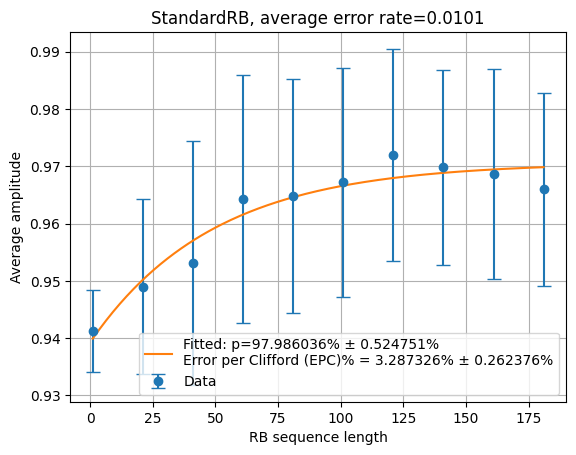

In [ ]:
default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
std_r_avg = np.abs(np.mean(rb_result, axis=1))
std_r_std = np.abs(np.std(rb_result, axis=1))

pOpt, pCov = fitrb(x, std_r_avg)

std_p_fit = pOpt[0]
std_p_fit_err = np.sqrt(pCov[0, 0])

epc = rb_error(p_fit, d=2)
epc_err = np.sqrt(error_fit_err(pCov[0, 0], d=2))

print(f"Fitted p = {std_p_fit*100:.6f} ± {std_p_fit_err*100:.6f}")
print(f"Error per Clifford (EPC)% = {epc*100:.6f} ± {epc_err*100:.6f}")
xfit = np.linspace(np.min(x), np.max(x), 200)
yfit = rb_func(xfit, *pOpt)


plt.errorbar(x, std_r_avg, yerr=std_r_std,fmt='o', label='Data', capsize=5)
plt.plot(xfit, yfit, '-', label=f'Fitted: p={std_p_fit*100:.6f}% ± {std_p_fit_err*100:.6f}%\
         \nError per Clifford (EPC)% = {epc*100:.6f}% ± {epc_err*100:.6f}%')
# plt.xscale('log')
plt.xlabel('RB sequence length')
plt.ylabel('Average amplitude')
plt.title(f'StandardRB, average error rate={rb_error(std_p_fit,2):.4f}')
# plt.title('InterleavedRB')
plt.grid(True)
plt.legend()
plt.show()

## interleve

In [ ]:
sxrb_result=[]
for i in tqdm(x, desc='depth'):
    rblist = []
    for _ in tqdm(range(number_sample), desc='number of sampe', leave=False):
        gate_char = "X/2"
        pulse_name_seq, total_clifford = interleaved_gate_sequence(i, gate_char=gate_char, debug=False)
        full_sequence = expand_full_sequence(pulse_name_seq, total_clifford)
        run_cfg['gate_seq'] = full_sequence

        rb=RB(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
        iq_list = rb.acquire(soc, soft_avgs=pyavg, progress=False)
        rblist.append(iq_list[0][0].dot([1,1j]))
    sxrb_result.append(rblist)

depth:   0%|          | 0/10 [00:00<?, ?it/s]

number of sampe:   0%|          | 0/60 [00:00<?, ?it/s]

number of sampe:   0%|          | 0/60 [00:00<?, ?it/s]

number of sampe:   0%|          | 0/60 [00:00<?, ?it/s]

number of sampe:   0%|          | 0/60 [00:00<?, ?it/s]

...

number of sampe:   0%|          | 0/60 [00:00<?, ?it/s]

number of sampe:   0%|          | 0/60 [00:00<?, ?it/s]

number of sampe:   0%|          | 0/60 [00:00<?, ?it/s]

number of sampe:   0%|          | 0/60 [00:00<?, ?it/s]

number of sampe:   0%|          | 0/60 [00:00<?, ?it/s]

Fitted p = 97.383151 ± 1.517795
Error per Clifford (EPC)% = 3.287326 ± 0.758897


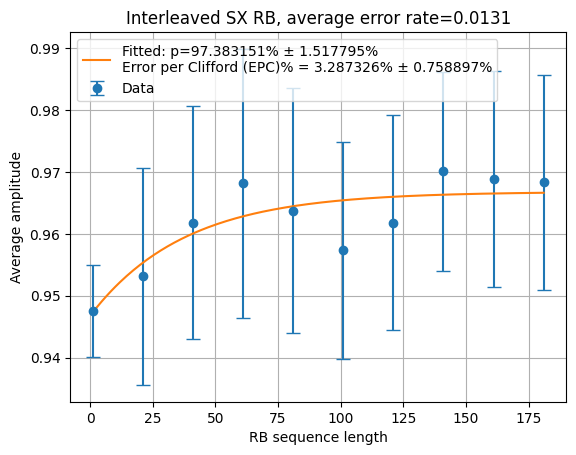

In [ ]:
default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
sx_r_avg = np.abs(np.mean(sxrb_result, axis=1))
sx_r_std = np.abs(np.std(sxrb_result, axis=1))

pOpt, pCov = fitrb(x, sx_r_avg)

sx_p_fit = pOpt[0]
sx_p_fit_err = np.sqrt(pCov[0, 0])

epc = rb_error(p_fit, d=2)
epc_err = np.sqrt(error_fit_err(pCov[0, 0], d=2))

print(f"Fitted p = {sx_p_fit*100:.6f} ± {sx_p_fit_err*100:.6f}")
print(f"Error per Clifford (EPC)% = {epc*100:.6f} ± {epc_err*100:.6f}")
xfit = np.linspace(np.min(x), np.max(x), 200)
yfit = rb_func(xfit, *pOpt)


plt.errorbar(x, sx_r_avg, yerr=sx_r_std,fmt='o', label='Data', capsize=5)
plt.plot(xfit, yfit, '-', label=f'Fitted: p={sx_p_fit*100:.6f}% ± {sx_p_fit_err*100:.6f}%\
         \nError per Clifford (EPC)% = {epc*100:.6f}% ± {epc_err*100:.6f}%')
plt.xlabel('RB sequence length')
plt.ylabel('Average amplitude')
plt.title(f'Interleaved SX RB, average error rate={rb_error(sx_p_fit,2):.4f}')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
xrb_result=[]
for i in tqdm(x, desc='depth'):
    rblist = []
    for _ in tqdm(range(number_sample), desc='number of sampe', leave=False):
        gate_char = "X"
        pulse_name_seq, total_clifford = interleaved_gate_sequence(i, gate_char=gate_char, debug=False)
        full_sequence = expand_full_sequence(pulse_name_seq, total_clifford)
        run_cfg['gate_seq'] = full_sequence

        rb=RB(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
        iq_list = rb.acquire(soc, soft_avgs=pyavg, progress=False)
        rblist.append(iq_list[0][0].dot([1,1j]))
    xrb_result.append(rblist)

depth:   0%|          | 0/10 [00:00<?, ?it/s]

number of sampe:   0%|          | 0/60 [00:00<?, ?it/s]

number of sampe:   0%|          | 0/60 [00:00<?, ?it/s]

number of sampe:   0%|          | 0/60 [00:00<?, ?it/s]

number of sampe:   0%|          | 0/60 [00:00<?, ?it/s]

...

number of sampe:   0%|          | 0/60 [00:00<?, ?it/s]

number of sampe:   0%|          | 0/60 [00:00<?, ?it/s]

number of sampe:   0%|          | 0/60 [00:00<?, ?it/s]

number of sampe:   0%|          | 0/60 [00:00<?, ?it/s]

number of sampe:   0%|          | 0/60 [00:00<?, ?it/s]

Fitted p = 99.043067 ± 0.433301
Error per Clifford (EPC)% = 3.287326 ± 0.216651


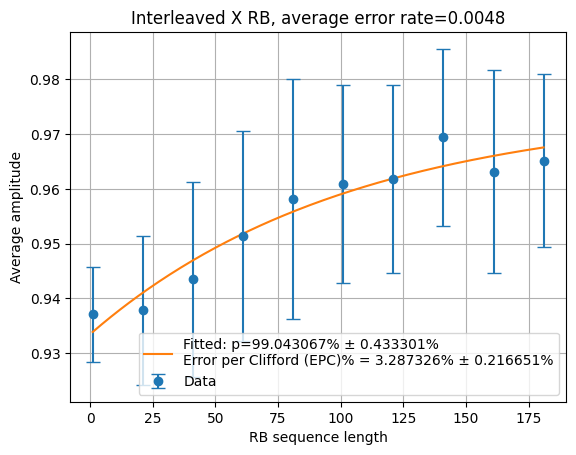

In [ ]:
default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
x_r_avg = np.abs(np.mean(xrb_result, axis=1))
x_r_std = np.abs(np.std(xrb_result, axis=1))

pOpt, pCov = fitrb(x, x_r_avg)

x_p_fit = pOpt[0]
x_p_fit_err = np.sqrt(pCov[0, 0])

epc = rb_error(p_fit, d=2)
epc_err = np.sqrt(error_fit_err(pCov[0, 0], d=2))

print(f"Fitted p = {x_p_fit*100:.6f} ± {x_p_fit_err*100:.6f}")
print(f"Error per Clifford (EPC)% = {epc*100:.6f} ± {epc_err*100:.6f}")
xfit = np.linspace(np.min(x), np.max(x), 200)
yfit = rb_func(xfit, *pOpt)

plt.errorbar(x, x_r_avg, yerr=x_r_std,fmt='o', label='Data', capsize=5)
plt.plot(xfit, yfit, '-', label=f'Fitted: p={x_p_fit*100:.6f}% ± {x_p_fit_err*100:.6f}%\
         \nError per Clifford (EPC)% = {epc*100:.6f}% ± {epc_err*100:.6f}%')
plt.xlabel('RB sequence length')
plt.ylabel('Average amplitude')
plt.title(f'Interleaved X RB, average error rate={rb_error(x_p_fit,2):.4f}')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
print(rb_gate_fidelity(std_p_fit, sx_p_fit, 2, std_p_fit_err, x_p_fit_err))
print(rb_gate_fidelity(std_p_fit, x_p_fit, 2, std_p_fit_err, x_p_fit_err))

(0.9969236150141217, 0.01706325273371956)
(1.0053937832013502, 0.025533420920948124)


# RB qiskit

In [ ]:
class RB(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        res_ch = cfg['res_ch']
        qubit_ch = cfg['qubit_ch']
        
        self.declare_gen(ch=res_ch, nqz=2)
        if soccfg['gens'][qubit_ch]['type']=='axis_sg_int4_v2':
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'], mixer_freq=cfg['qmixer_freq'])
        else:
            self.declare_gen(ch=qubit_ch, nqz=cfg['nqz'])
        # pynq configured
        # self.declare_readout(ch=ro_ch, length=cfg['ro_len'], freq=cfg['f_res'], gen_ch=res_ch)
        
        # tproc configured
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['f_res'], gen_ch=res_ch)
        
        self.add_pulse(ch=res_ch, name="res_pulse", ro_ch=ro_ch, 
                       style="const", 
                       length=cfg['res_len'], 
                       freq=cfg['f_res'], 
                       phase=cfg['res_phase'],
                       gain=cfg['res_gain'],
                      )
        
        self.add_gauss(ch=qubit_ch, name="ramp", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
        if cfg['qb_pulse_style']=='arb':
            ## X pulse ##
            self.add_pulse(ch=qubit_ch, name="rx(pi)", 
                        style="arb", 
                        envelope="ramp", 
                        freq=cfg['f_ge'],
                        phase=0,
                        gain=cfg['pi_gain'], 
                        )
            self.add_pulse(ch=qubit_ch, name="rx(-pi)", 
                        style="arb", 
                        envelope="ramp", 
                        freq=cfg['f_ge'],
                        phase=0,
                        gain=-cfg['pi_gain'], 
                        )
            self.add_pulse(ch=qubit_ch, name="rx(pi/2)", 
                    style="arb", 
                    envelope="ramp", 
                    freq=cfg['f_ge'], 
                    phase=0,
                    gain=cfg['pi2_gain'], 
                    )
            self.add_pulse(ch=qubit_ch, name="rx(-pi/2)", 
                    style="arb", 
                    envelope="ramp", 
                    freq=cfg['f_ge'], 
                    phase=0,
                    gain=-cfg['pi2_gain'], 
                    )
            ## Y pulse ##
            self.add_pulse(ch=qubit_ch, name="ry(pi)", 
                        style="arb", 
                        envelope="ramp", 
                        freq=cfg['f_ge'],
                        phase=90,
                        gain=cfg['pi_gain'], 
                        )
            self.add_pulse(ch=qubit_ch, name="ry(-pi)", 
                        style="arb", 
                        envelope="ramp", 
                        freq=cfg['f_ge'],
                        phase=90,
                        gain=-cfg['pi_gain'], 
                        )
            self.add_pulse(ch=qubit_ch, name="ry(pi/2)", 
                    style="arb", 
                    envelope="ramp", 
                    freq=cfg['f_ge'], 
                    phase=90,
                    gain=cfg['pi2_gain'], 
                    )
            self.add_pulse(ch=qubit_ch, name="ry(-pi/2)", 
                    style="arb", 
                    envelope="ramp", 
                    freq=cfg['f_ge'], 
                    phase=90,
                    gain=-cfg['pi2_gain'], 
                    )


    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        for i in self.cfg['gate_seq']:
            if i=='barrier':
                pass
            else:
                self.pulse(ch=self.cfg["qubit_ch"], name=f"{i}", t=0) 
                self.delay_auto(0.0)

        self.delay_auto(0.05) # wait_time after last pulse
        self.pulse(ch=cfg['res_ch'], name="res_pulse", t=0) # play probe pulse
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

In [ ]:
exp = InterleavedRB(SXGate(), [0], [100], num_samples=10)
circs = exp.circuits()
circ = circs[0]
qasm = transpile(circ.decompose(), basis_gates=['rx', 'ry'])
# qasm.draw()
pattern = r'rx\([^\)]+\)|ry\([^\)]+\)|barrier'
qasm_str = qasm3.dumps(qasm, experimental=qasm3.ExperimentalFeatures.SWITCH_CASE_V1)
matches = re.findall(pattern, qasm_str)
len(matches)

302

In [ ]:
from qiskit import transpile
from qiskit_experiments.library import StandardRB, InterleavedRB
from qiskit.circuit.library import XGate, SXGate
from qiskit import qasm3, QuantumCircuit, QuantumRegister, ClassicalRegister
import re

# xdata = np.unique(np.logspace(0.4, 3, 10).astype(int))
xdata = np.arange(1, 151, 10)
ydata_list = np.arange(50)

pyavg = 100
rblist_len = []

for i in tqdm(xdata, desc='depth'):
    rblist = []

    exp = StandardRB([0], [i], num_samples=len(ydata_list))
    # exp = InterleavedRB(XGate(), [0], [i], num_samples=len(ydata_list))
    circs = exp.circuits()

    for n in tqdm(range(len(ydata_list)), leave=False, desc='reps'):
        circ = circs[n]
        qasm = transpile(circ.decompose(), basis_gates=['rx', 'ry'])
        qasm_str = qasm3.dumps(qasm, experimental=qasm3.ExperimentalFeatures.SWITCH_CASE_V1)

        pattern = r'rx\([^\)]+\)|ry\([^\)]+\)|barrier'
        matches = re.findall(pattern, qasm_str)

        run_cfg['gate_seq'] = matches

        rb = RB(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
        iq_list = rb.acquire(soc, soft_avgs=pyavg, progress=False)

        rblist.append(iq_list[0][0].dot([1, 1j]))
    rblist_len.append(rblist)


depth:   0%|          | 0/15 [00:00<?, ?it/s]

reps:   0%|          | 0/50 [00:00<?, ?it/s]

reps:   0%|          | 0/50 [00:00<?, ?it/s]

reps:   0%|          | 0/50 [00:00<?, ?it/s]

reps:   0%|          | 0/50 [00:00<?, ?it/s]

...

reps:   0%|          | 0/50 [00:00<?, ?it/s]

reps:   0%|          | 0/50 [00:00<?, ?it/s]

reps:   0%|          | 0/50 [00:00<?, ?it/s]

reps:   0%|          | 0/50 [00:00<?, ?it/s]

reps:   0%|          | 0/50 [00:00<?, ?it/s]

Fitted p = 95.50 ± 0.14
Error per Clifford (EPC)% = 2.25 ± 0.07


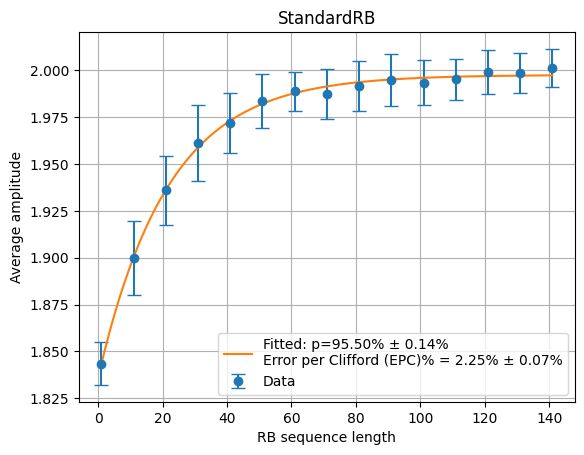

In [ ]:
r_avg = np.abs(np.mean(rblist_len, axis=1))
r_std = np.abs(np.std(rblist_len, axis=1))

pOpt, pCov = fitrb(xdata, r_avg)

p_fit = pOpt[0]
p_fit_err = np.sqrt(pCov[0, 0])

epc = rb_error(p_fit, d=2)
epc_err = np.sqrt(error_fit_err(pCov[0, 0], d=2))

print(f"Fitted p = {p_fit*100:.2f} ± {p_fit_err*100:.2f}")
print(f"Error per Clifford (EPC)% = {epc*100:.2f} ± {epc_err*100:.2f}")
xfit = np.linspace(np.min(xdata), np.max(xdata), 200)
yfit = rb_func(xfit, *pOpt)


plt.errorbar(xdata, r_avg, yerr=r_std,fmt='o', label='Data', capsize=5)
plt.plot(xfit, yfit, '-', label=f'Fitted: p={p_fit*100:.2f}% ± {p_fit_err*100:.2f}%\
         \nError per Clifford (EPC)% = {epc*100:.2f}% ± {epc_err*100:.2f}%')
# plt.xscale('log')
plt.xlabel('RB sequence length')
plt.ylabel('Average amplitude')
plt.title('StandardRB')
# plt.title('InterleavedRB')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
from qiskit import transpile
from qiskit_experiments.library import StandardRB, InterleavedRB
from qiskit.circuit.library import XGate, SXGate
from qiskit import qasm3, QuantumCircuit, QuantumRegister, ClassicalRegister
import re

xdata = np.unique(np.logspace(0.4, 2.5, 50).astype(int))
xdata = np.arange(1, 201, 10)
ydata_list = np.arange(15)

pyavg = 100

std_rblist_len = []
for i in tqdm(xdata, desc='depth'):
    rblist = []

    exp = StandardRB([0], [i], num_samples=len(ydata_list))
    # exp = InterleavedRB(XGate(), [0], [i], num_samples=len(ydata_list))
    circs = exp.circuits()

    for n in tqdm(range(len(ydata_list)), leave=False, desc='reps'):
        circ = circs[n]
        qasm = transpile(circ.decompose(), basis_gates=['rx', 'ry'])
        qasm_str = qasm3.dumps(qasm, experimental=qasm3.ExperimentalFeatures.SWITCH_CASE_V1)

        pattern = r'rx\([^\)]+\)|ry\([^\)]+\)|barrier'
        matches = re.findall(pattern, qasm_str)

        run_cfg['gate_seq'] = matches

        rb = RB(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
        iq_list = rb.acquire(soc, soft_avgs=pyavg, progress=False)

        rblist.append(iq_list[0][0].dot([1, 1j]))
    std_rblist_len.append(rblist)

x_rblist_len = []
for i in tqdm(xdata, desc='depth'):
    rblist = []

    # exp = StandardRB([0], [i], num_samples=len(ydata_list))
    exp = InterleavedRB(XGate(), [0], [i], num_samples=len(ydata_list))
    circs = exp.circuits()

    for n in tqdm(range(len(ydata_list)), leave=False, desc='reps'):
        circ = circs[n]
        qasm = transpile(circ.decompose(), basis_gates=['rx', 'ry'])
        qasm_str = qasm3.dumps(qasm, experimental=qasm3.ExperimentalFeatures.SWITCH_CASE_V1)

        pattern = r'rx\([^\)]+\)|ry\([^\)]+\)|barrier'
        matches = re.findall(pattern, qasm_str)

        run_cfg['gate_seq'] = matches

        rb = RB(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
        iq_list = rb.acquire(soc, soft_avgs=pyavg, progress=False)

        rblist.append(iq_list[0][0].dot([1, 1j]))
    x_rblist_len.append(rblist)

sx_rblist_len = []
for i in tqdm(xdata, desc='depth'):
    rblist = []

    # exp = StandardRB([0], [i], num_samples=len(ydata_list))
    exp = InterleavedRB(SXGate(), [0], [i], num_samples=len(ydata_list))
    circs = exp.circuits()

    for n in tqdm(range(len(ydata_list)), leave=False, desc='reps'):
        circ = circs[n]
        qasm = transpile(circ.decompose(), basis_gates=['rx', 'ry'])
        qasm_str = qasm3.dumps(qasm, experimental=qasm3.ExperimentalFeatures.SWITCH_CASE_V1)

        pattern = r'rx\([^\)]+\)|ry\([^\)]+\)|barrier'
        matches = re.findall(pattern, qasm_str)

        run_cfg['gate_seq'] = matches

        rb = RB(soccfg, reps=100, final_delay=run_cfg['relax_delay'], cfg=run_cfg)
        iq_list = rb.acquire(soc, soft_avgs=pyavg, progress=False)

        rblist.append(iq_list[0][0].dot([1, 1j]))
    sx_rblist_len.append(rblist)


depth:   0%|          | 0/20 [00:00<?, ?it/s]

reps:   0%|          | 0/15 [00:00<?, ?it/s]

reps:   0%|          | 0/15 [00:00<?, ?it/s]

reps:   0%|          | 0/15 [00:00<?, ?it/s]

reps:   0%|          | 0/15 [00:00<?, ?it/s]

...

reps:   0%|          | 0/15 [00:00<?, ?it/s]

reps:   0%|          | 0/15 [00:00<?, ?it/s]

reps:   0%|          | 0/15 [00:00<?, ?it/s]

reps:   0%|          | 0/15 [00:00<?, ?it/s]

reps:   0%|          | 0/15 [00:00<?, ?it/s]

In [ ]:
np.savez('stdrb.npz', x=xdata, y=std_rblist_len)
np.savez('xrb.npz', x=xdata, y=x_rblist_len)
np.savez('sxrb.npz', x=xdata, y=sx_rblist_len)

In [ ]:
std = np.load('rb.npz')
xrb = np.load('xrb.npz')
sxrb = np.load('sxrb.npz')

Fitted std: p = 99.97 ± 0.39
Error per Clifford (EPC)% = 0.02 ± 0.19


<Figure size 800x600 with 0 Axes>

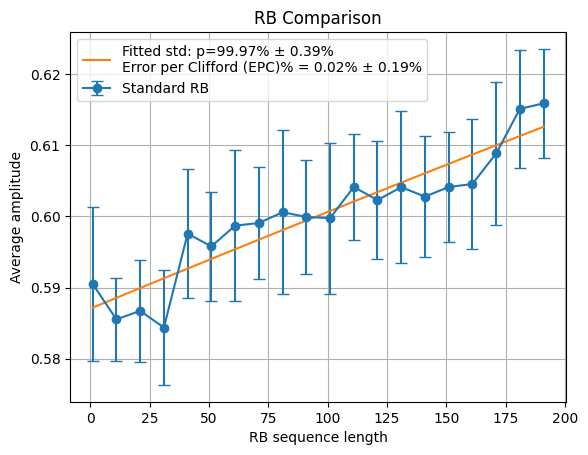

Fitted x: p = 99.54 ± 0.32
Error per Clifford (EPC)% = 0.23 ± 0.16


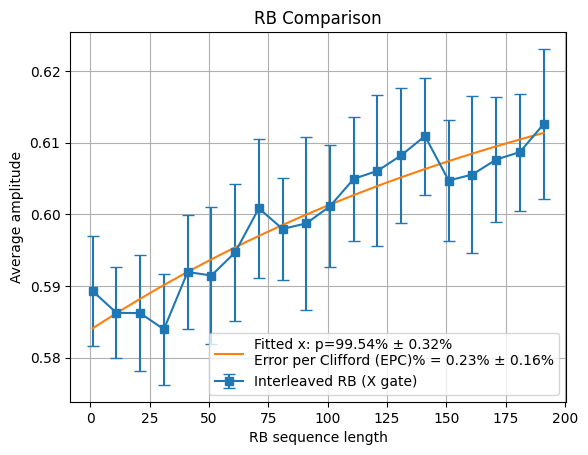

Fitted sx: p = 98.91 ± 0.41
Error per Clifford (EPC)% = 0.55 ± 0.21


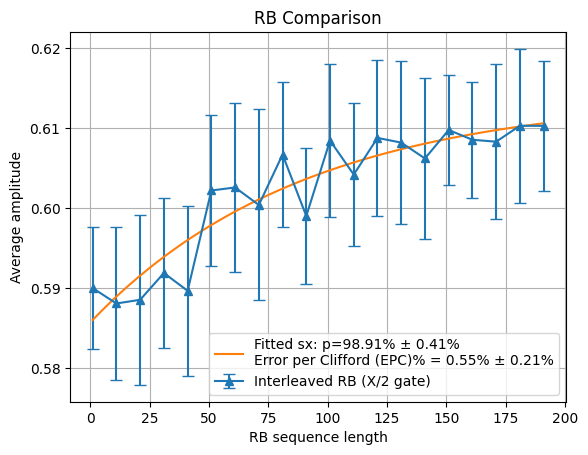

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
r_avg = np.abs(np.mean(std_rblist_len, axis=1))
r_std = np.abs(np.std(std_rblist_len, axis=1))
xrb_avg = np.abs(np.mean(x_rblist_len, axis=1))
xrb_err = np.abs(np.std(x_rblist_len, axis=1))
sxrb_avg = np.abs(np.mean(sx_rblist_len, axis=1))
sxrb_err = np.abs(np.std(sx_rblist_len, axis=1))

sequence_len = xdata
# rb_avg = std['y']
# rb_err = std['sigma']

# xrb_avg = xrb['y']
# xrb_err = xrb['sigma']

# sxrb_avg = sxrb['y']
# sxrb_err = sxrb['sigma']

plt.figure(figsize=(8,6))
plt.figure()
pOpt, pCov = fitrb(sequence_len, r_avg)
p_fit = pOpt[0]
p_fit_err = np.sqrt(pCov[0, 0])
epc = rb_error(p_fit, d=2)
epc_err = np.sqrt(error_fit_err(pCov[0, 0], d=2))
print(f"Fitted std: p = {p_fit*100:.2f} ± {p_fit_err*100:.2f}")
print(f"Error per Clifford (EPC)% = {epc*100:.2f} ± {epc_err*100:.2f}")
xfit = np.linspace(np.min(sequence_len), np.max(sequence_len), 200)
yfit = rb_func(xfit, *pOpt)
plt.errorbar(sequence_len, r_avg, yerr=r_std, fmt='o-', capsize=4, label='Standard RB')
plt.plot(xfit, yfit, '-', label=f'Fitted std: p={p_fit*100:.2f}% ± {p_fit_err*100:.2f}%\
         \nError per Clifford (EPC)% = {epc*100:.2f}% ± {epc_err*100:.2f}%')
plt.xlabel('RB sequence length')
plt.ylabel('Average amplitude')
plt.title('RB Comparison')
plt.grid(True)
plt.legend()
plt.show()

plt.figure()
pOpt, pCov = fitrb(sequence_len, xrb_avg)
p_fit = pOpt[0]
p_fit_err = np.sqrt(pCov[0, 0])
epc = rb_error(p_fit, d=2)
epc_err = np.sqrt(error_fit_err(pCov[0, 0], d=2))
print(f"Fitted x: p = {p_fit*100:.2f} ± {p_fit_err*100:.2f}")
print(f"Error per Clifford (EPC)% = {epc*100:.2f} ± {epc_err*100:.2f}")
xfit = np.linspace(np.min(sequence_len), np.max(sequence_len), 200)
yfit = rb_func(xfit, *pOpt)
plt.errorbar(sequence_len, xrb_avg, yerr=xrb_err, fmt='s-', capsize=4, label='Interleaved RB (X gate)')
plt.plot(xfit, yfit, '-', label=f'Fitted x: p={p_fit*100:.2f}% ± {p_fit_err*100:.2f}%\
         \nError per Clifford (EPC)% = {epc*100:.2f}% ± {epc_err*100:.2f}%')
plt.xlabel('RB sequence length')
plt.ylabel('Average amplitude')
plt.title('RB Comparison')
plt.grid(True)
plt.legend()
plt.show()

plt.figure()
pOpt, pCov = fitrb(sequence_len, sxrb_avg)
p_fit = pOpt[0]
p_fit_err = np.sqrt(pCov[0, 0])
epc = rb_error(p_fit, d=2)
epc_err = np.sqrt(error_fit_err(pCov[0, 0], d=2))
print(f"Fitted sx: p = {p_fit*100:.2f} ± {p_fit_err*100:.2f}")
print(f"Error per Clifford (EPC)% = {epc*100:.2f} ± {epc_err*100:.2f}")
xfit = np.linspace(np.min(sequence_len), np.max(sequence_len), 200)
yfit = rb_func(xfit, *pOpt)
plt.errorbar(sequence_len, sxrb_avg, yerr=sxrb_err, fmt='^-', capsize=4, label='Interleaved RB (X/2 gate)')
plt.plot(xfit, yfit, '-', label=f'Fitted sx: p={p_fit*100:.2f}% ± {p_fit_err*100:.2f}%\
         \nError per Clifford (EPC)% = {epc*100:.2f}% ± {epc_err*100:.2f}%')

plt.xlabel('RB sequence length')
plt.ylabel('Average amplitude')
plt.title('RB Comparison')
plt.grid(True)
plt.legend()
plt.show()
